<a href="https://colab.research.google.com/github/Leonanda1013/Telco-Customer-Churn/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduce
**Nama** : Vincentius Leonanda Prabowo <br>
**Role** : AI Engineer

---
<span>

**Dataset:** <br>
https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data
<span>

---

**Tujuan:** <br>
--> Tujuan utama dari proyek ini adalah membangun model machine learning yang mampu memprediksi kemungkinan seorang pelanggan akan berhenti berlangganan (churn) berdasarkan data perilaku penggunaan dan demografi pelanggan. Dengan prediksi ini, perusahaan dapat mengambil tindakan lebih awal untuk mempertahankan pelanggan yang berisiko tinggi.

------
**Pipeline:**
1. Load Dataset
2. Cleaning
3. EDA
4. Feature Engineering
5. Modeling
6. Tuning
7. Save Model

# Environment

In [138]:
!pip install optuna

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, normaltest, shapiro
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
import joblib
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
import random

# Load Dataset

In [140]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [142]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Data Cleaning

Benahi TotalCharges

In [143]:
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
print("Jumlah null:", mask.sum())
print()
df[mask]

Jumlah null: 11



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [144]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("Missing values:", df['TotalCharges'].isna().sum())

TotalCharges dtype: float64
Missing values: 0


Hapus CustomerID

In [145]:
df = df.drop('customerID', axis=1)
print("Shape setelah drop customerID:", df.shape)

Shape setelah drop customerID: (7043, 20)


Cek Missing Value

In [146]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing:", df.isnull().sum().sum())

Missing values per column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing: 0


Cek Duplikat Data

In [147]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 22


In [148]:
df = df.drop_duplicates()

In [149]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = [c for c in cat_cols if c != 'Churn']

print("Fitur Kategori:", cat_cols)
print("Count:", len(cat_cols))
print()
print("Fitur Numerik:", num_cols)
print("Count:", len(num_cols))

Fitur Kategori: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Count: 16

Fitur Numerik: ['tenure', 'MonthlyCharges', 'TotalCharges']
Count: 3


# EDA

Target value counts:
Churn
No     5164
Yes    1857
Name: count, dtype: int64

Target proportions:
Churn
No     0.736
Yes    0.264
Name: proportion, dtype: float64


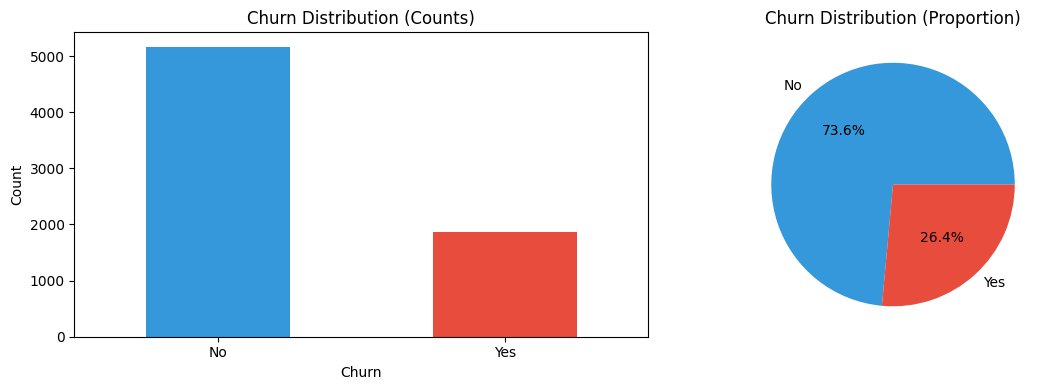


Imbalance ratio: 2.78:1


In [150]:
print("Target value counts:")
print(df['Churn'].value_counts())
print()
print("Target proportions:")
print(df['Churn'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Churn Distribution (Counts)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=['#3498db', '#e74c3c'])
axes[1].set_ylabel('')
axes[1].set_title('Churn Distribution (Proportion)')

plt.tight_layout()
plt.show()

# Imbalance ratio
majority = df['Churn'].value_counts().max()
minority = df['Churn'].value_counts().min()
print(f"\nImbalance ratio: {majority/minority:.2f}:1")

## Univariate Analysis

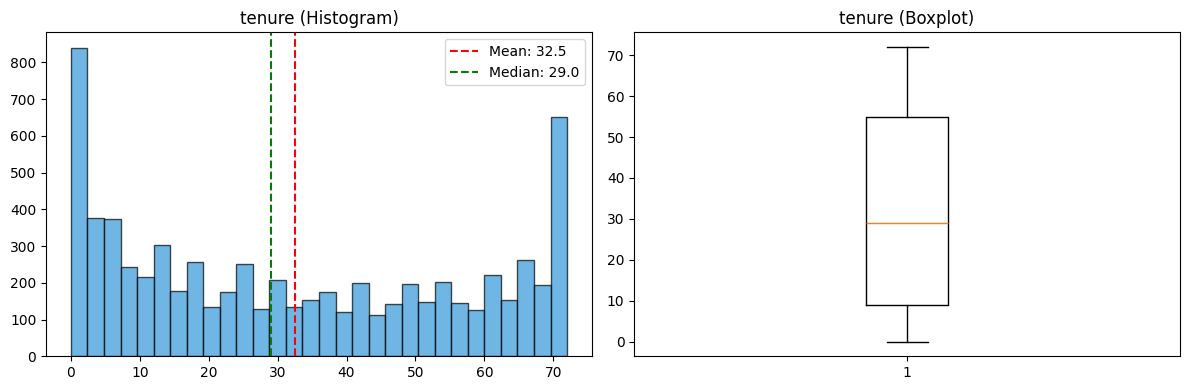

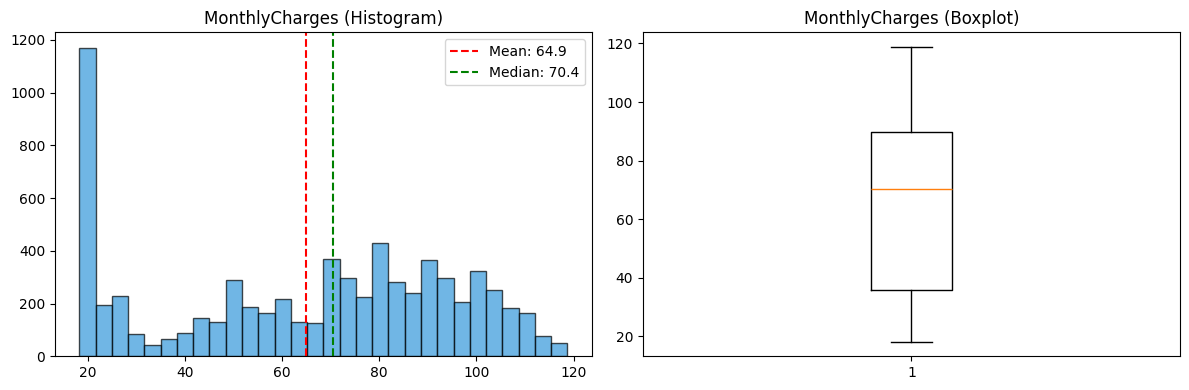

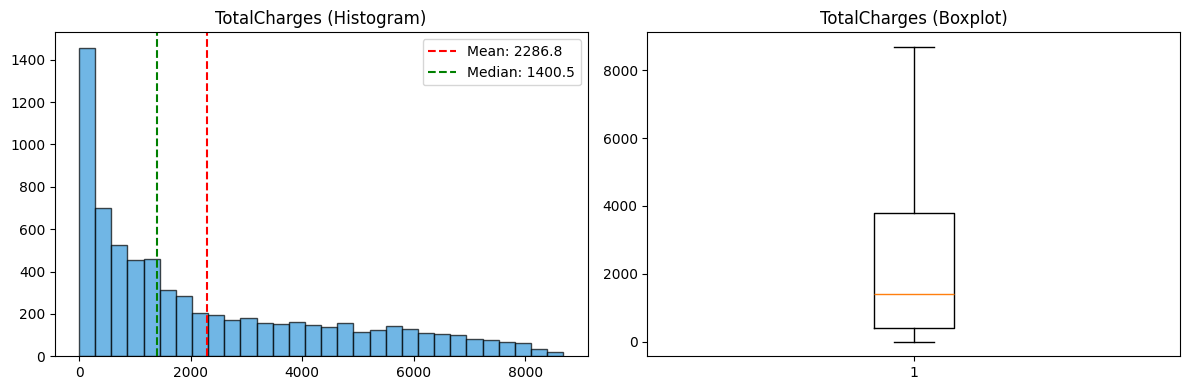

In [151]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[0].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[0].set_title(f'{col} (Histogram)')
    axes[0].legend()

    axes[1].boxplot(df[col], vert=True)
    axes[1].set_title(f'{col} (Boxplot)')

    plt.tight_layout()
    plt.show()

In [152]:
print("Extended Statistics:")
print(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

Extended Statistics:
        tenure  MonthlyCharges  TotalCharges
count  7021.00         7021.00       7021.00
mean     32.47           64.85       2286.77
std      24.53           30.07       2266.86
min       0.00           18.25          0.00
1%        1.00           19.20         19.75
5%        1.00           19.65         49.80
25%       9.00           35.75        403.35
50%      29.00           70.40       1400.55
75%      55.00           89.90       3801.70
95%      72.00          107.45       6925.90
99%      72.00          114.74       8040.51
max      72.00          118.75       8684.80


/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


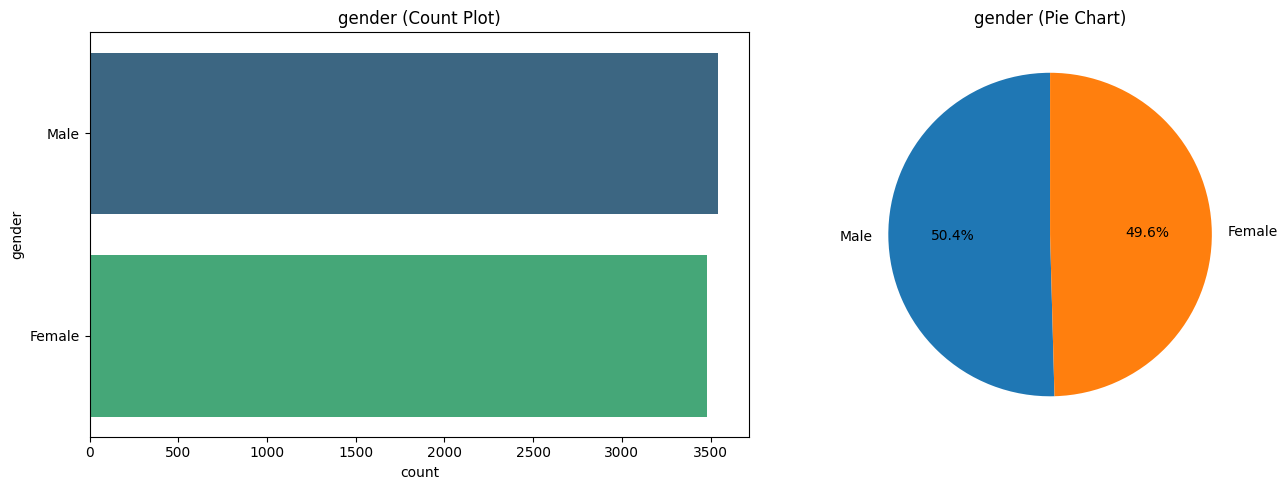

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


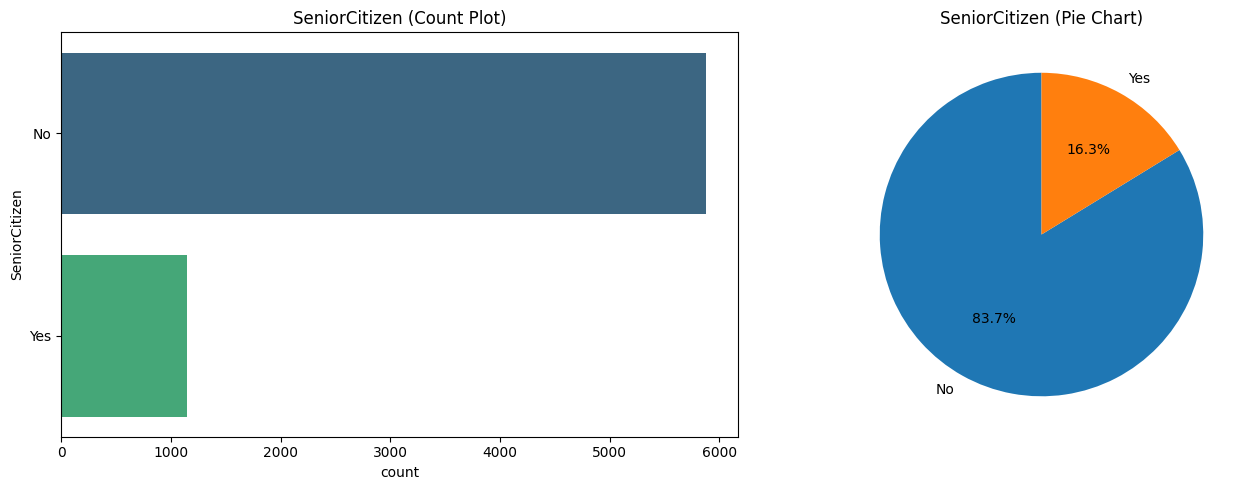

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


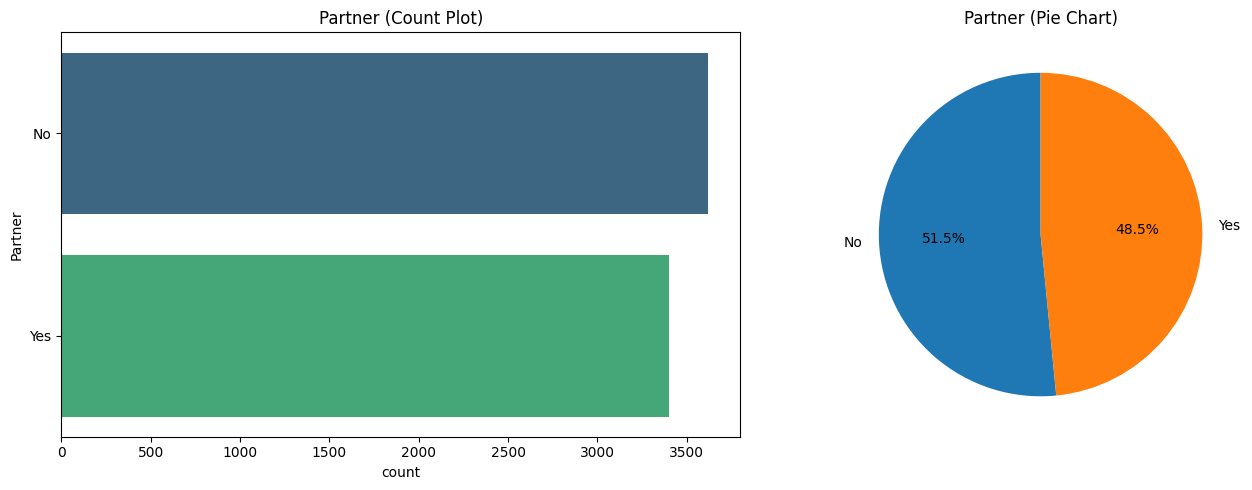

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


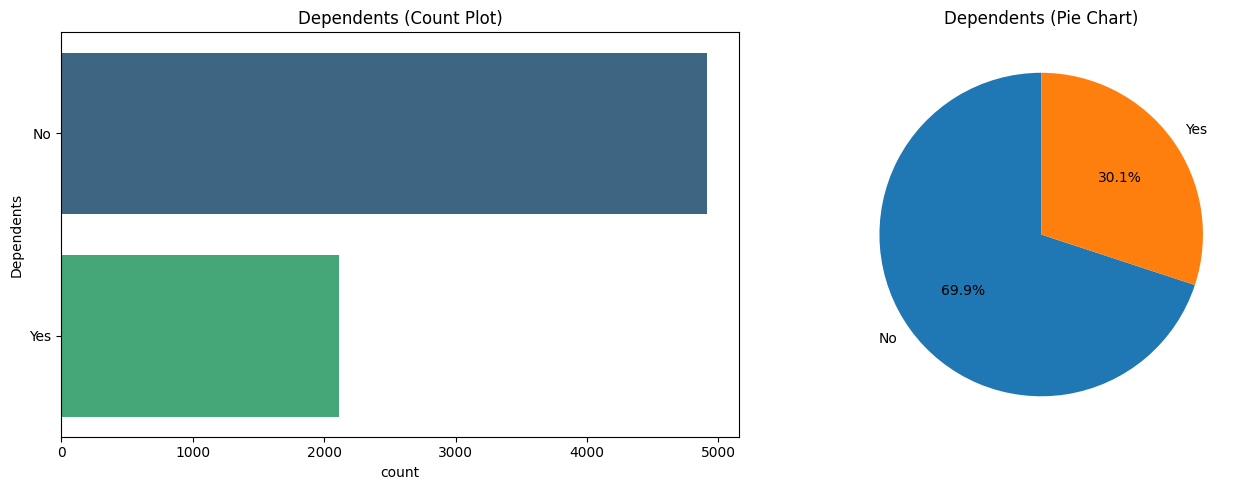

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


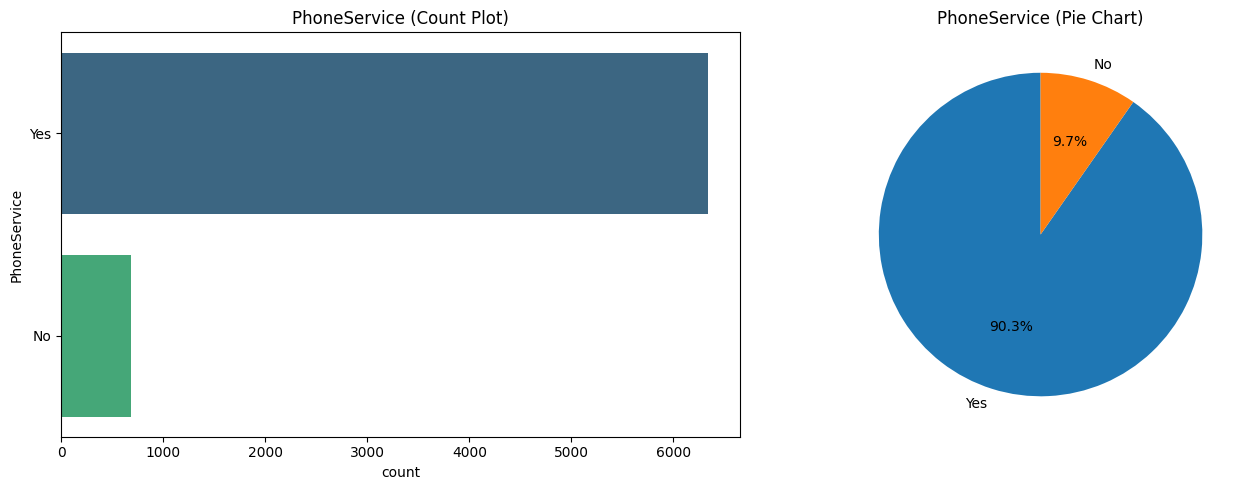

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


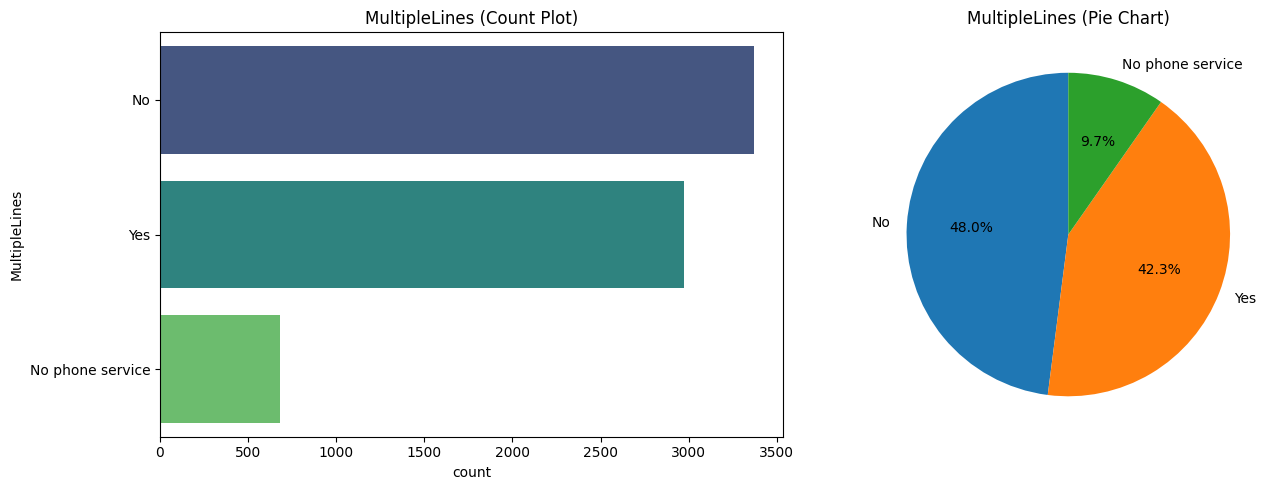

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


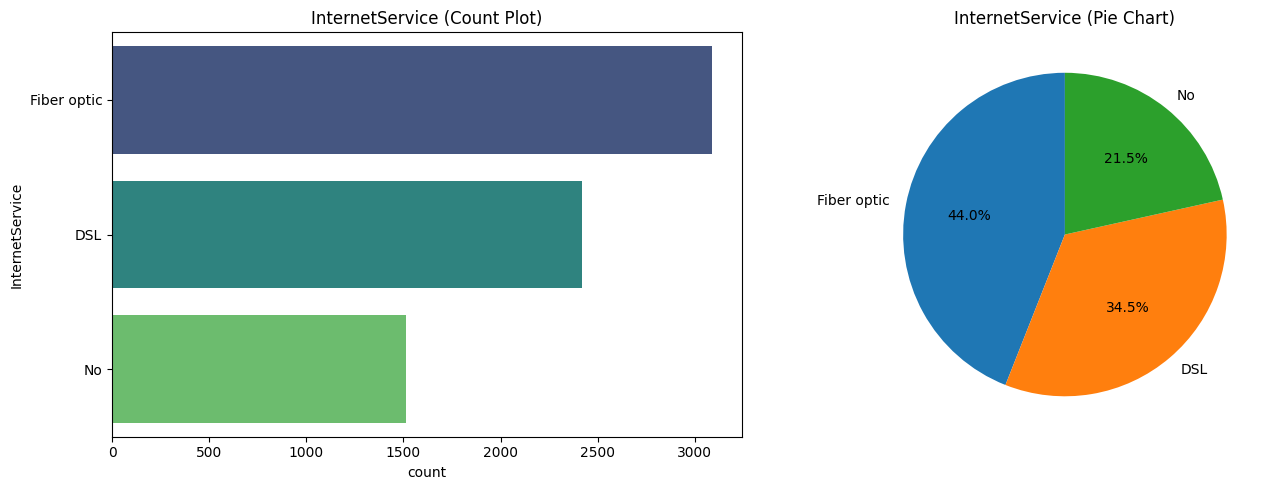

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


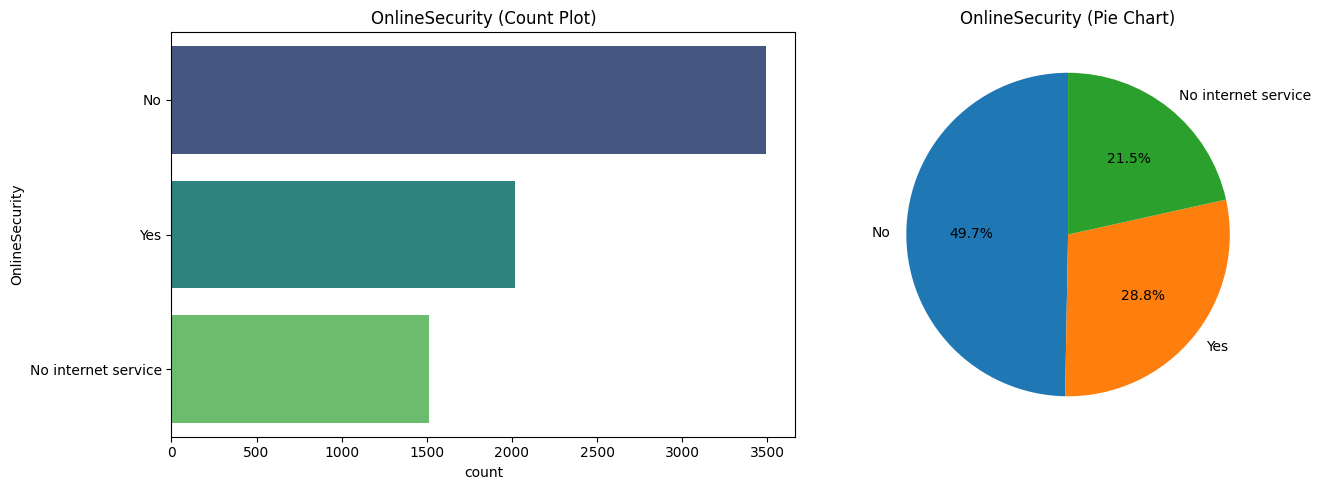

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


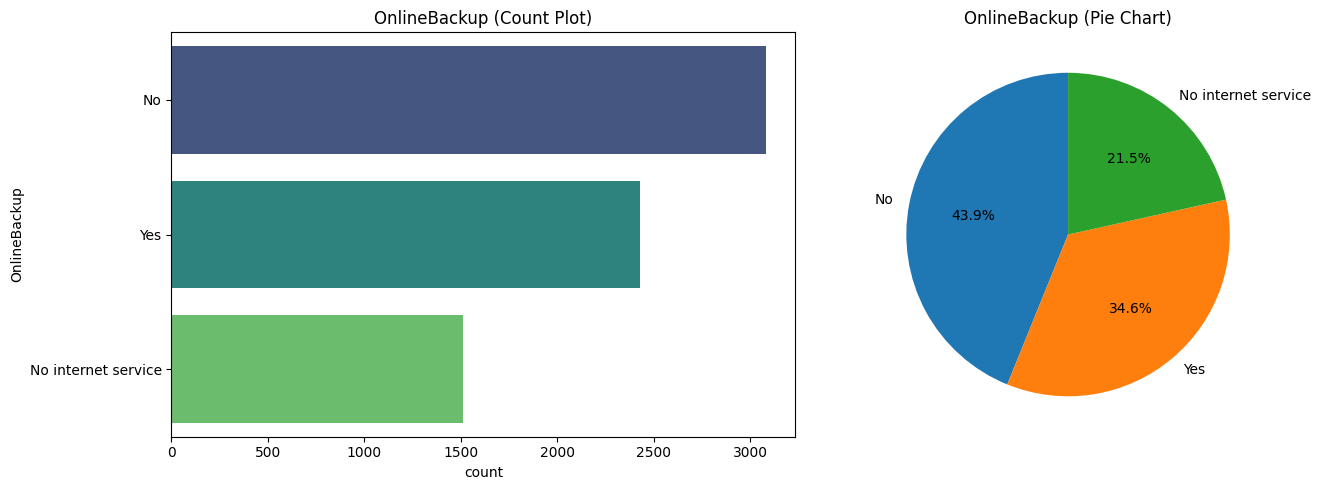

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


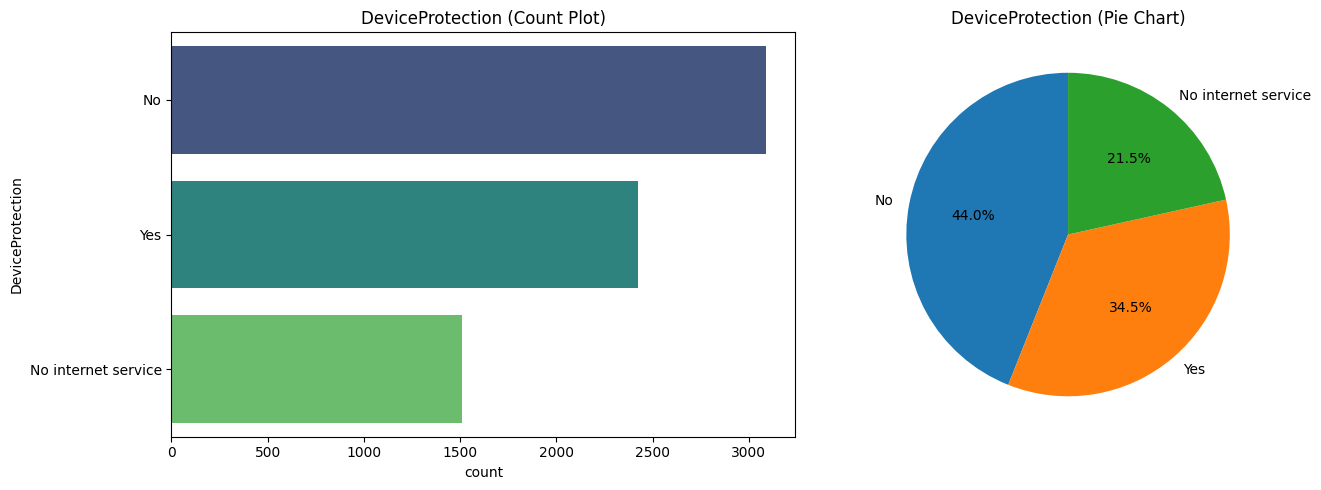

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


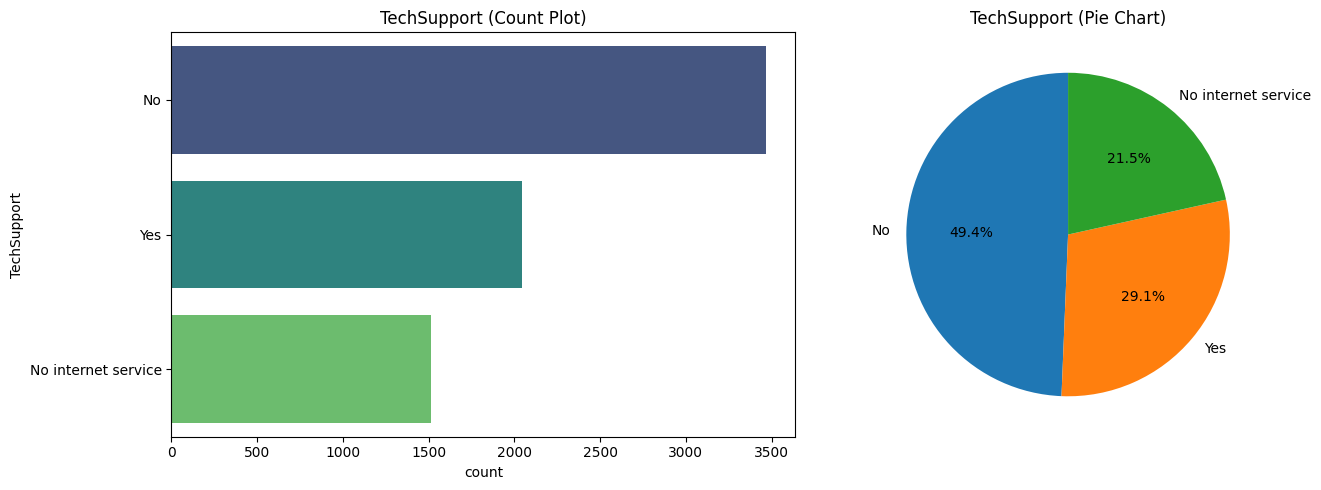

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


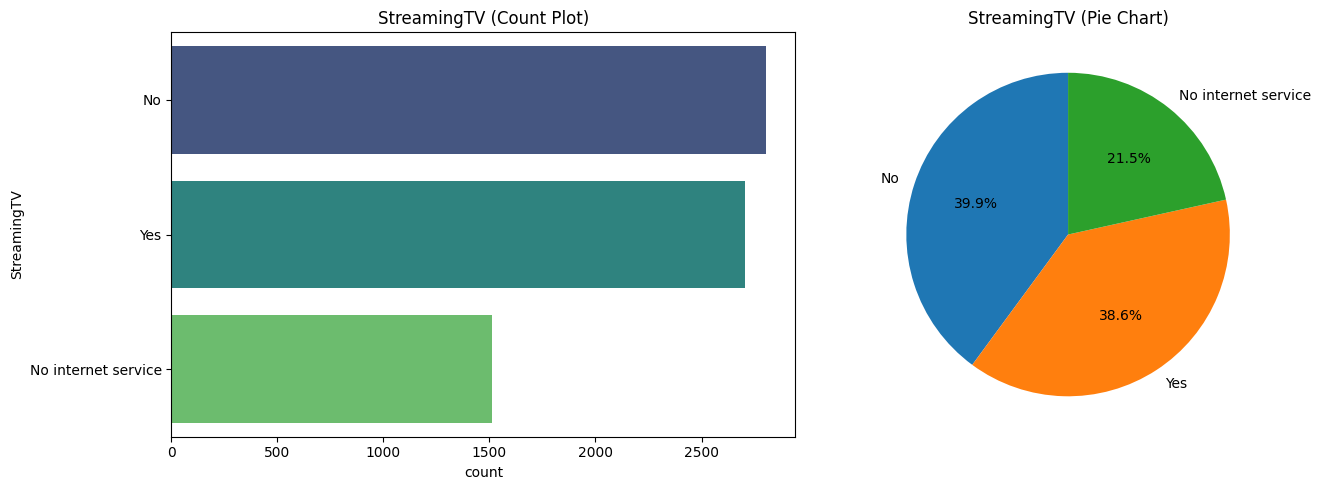

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


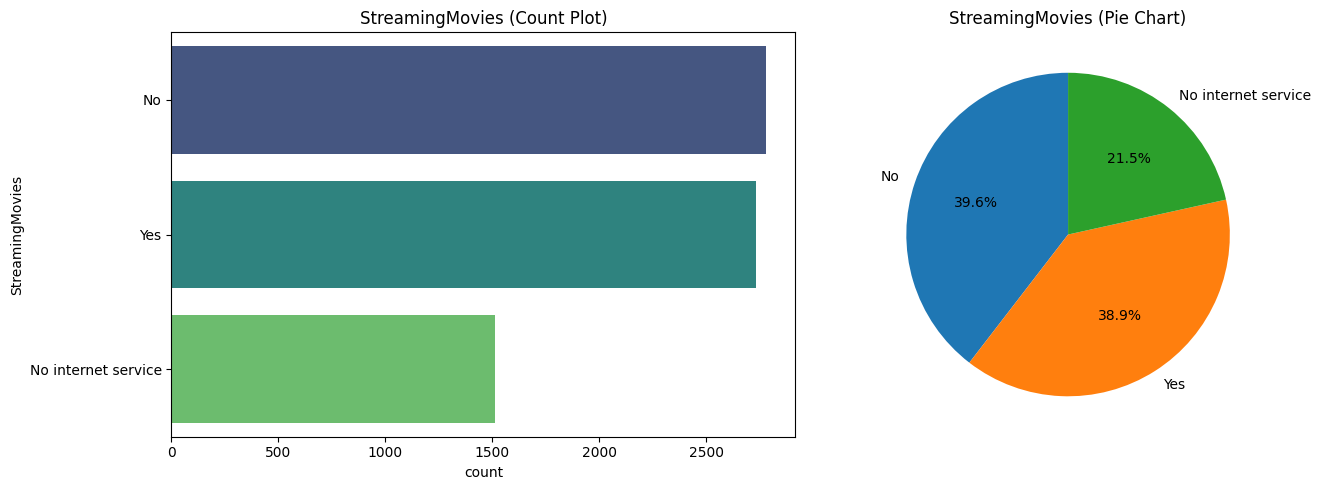

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


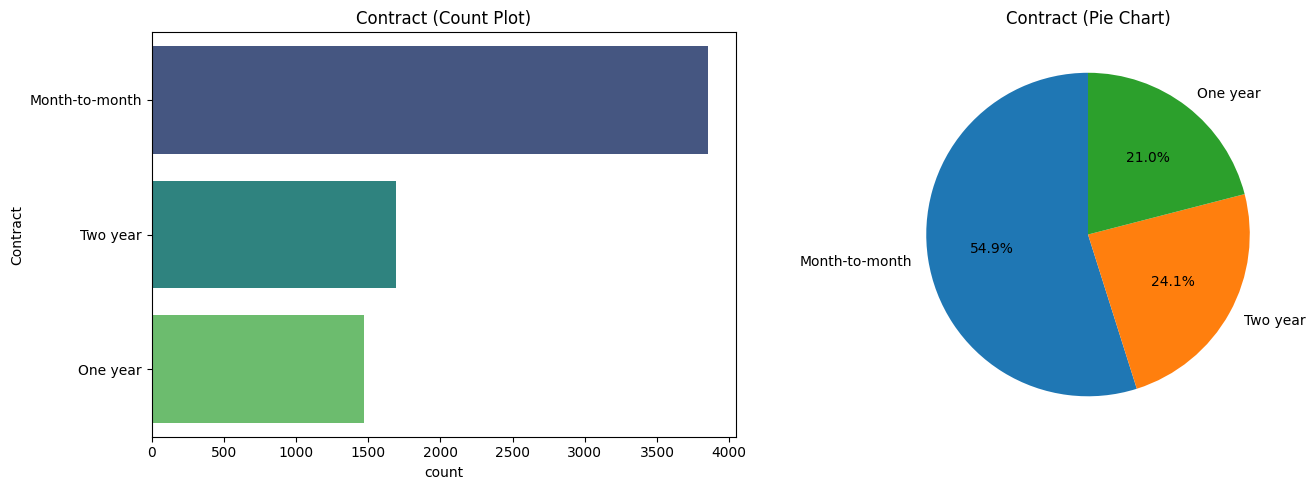

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


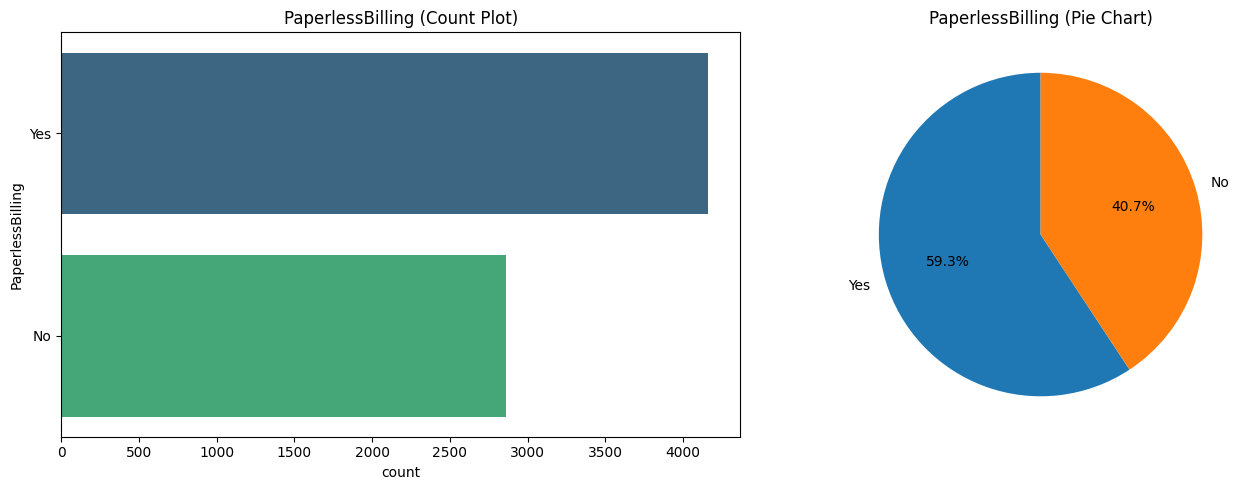

/tmp/ipykernel_5052/345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


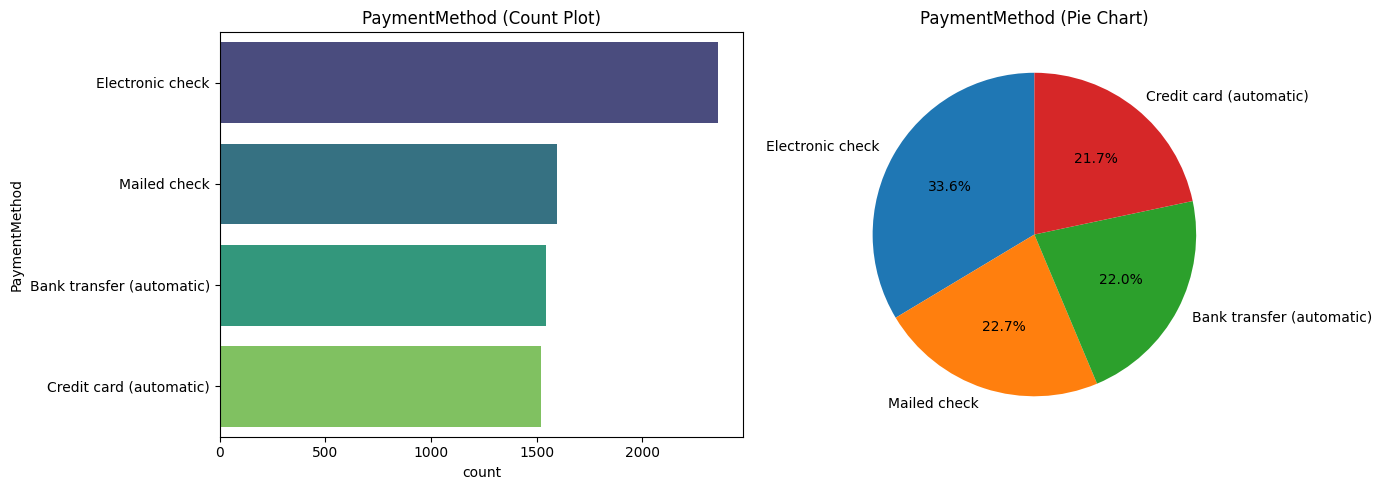

In [153]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')
    axes[0].set_title(f'{col} (Count Plot)')

    counts = df[col].value_counts()
    if len(counts) > 8:
        top = counts.head(7)
        top['Other'] = counts.iloc[7:].sum()
        counts = top
    counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'{col} (Pie Chart)')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

In [154]:
print("Cardinality of categorical features:")
print("-" * 35)
for col in cat_cols:
    print(f"  {col:20s}: {df[col].nunique()} unique values")

Cardinality of categorical features:
-----------------------------------
  gender              : 2 unique values
  SeniorCitizen       : 2 unique values
  Partner             : 2 unique values
  Dependents          : 2 unique values
  PhoneService        : 2 unique values
  MultipleLines       : 3 unique values
  InternetService     : 3 unique values
  OnlineSecurity      : 3 unique values
  OnlineBackup        : 3 unique values
  DeviceProtection    : 3 unique values
  TechSupport         : 3 unique values
  StreamingTV         : 3 unique values
  StreamingMovies     : 3 unique values
  Contract            : 3 unique values
  PaperlessBilling    : 2 unique values
  PaymentMethod       : 4 unique values


## Bivariate Analysis

/tmp/ipykernel_5052/11429008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[0], palette=['#3498db', '#e74c3c'])
/tmp/ipykernel_5052/11429008.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y=col, ax=axes[1], palette=['#3498db', '#e74c3c'])


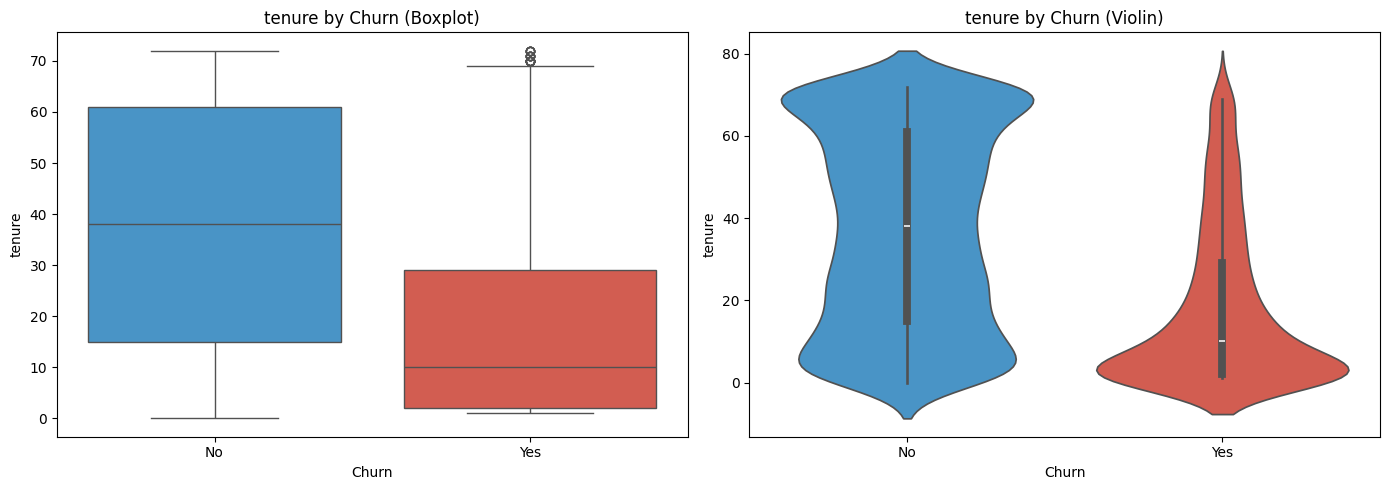

/tmp/ipykernel_5052/11429008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[0], palette=['#3498db', '#e74c3c'])
/tmp/ipykernel_5052/11429008.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y=col, ax=axes[1], palette=['#3498db', '#e74c3c'])


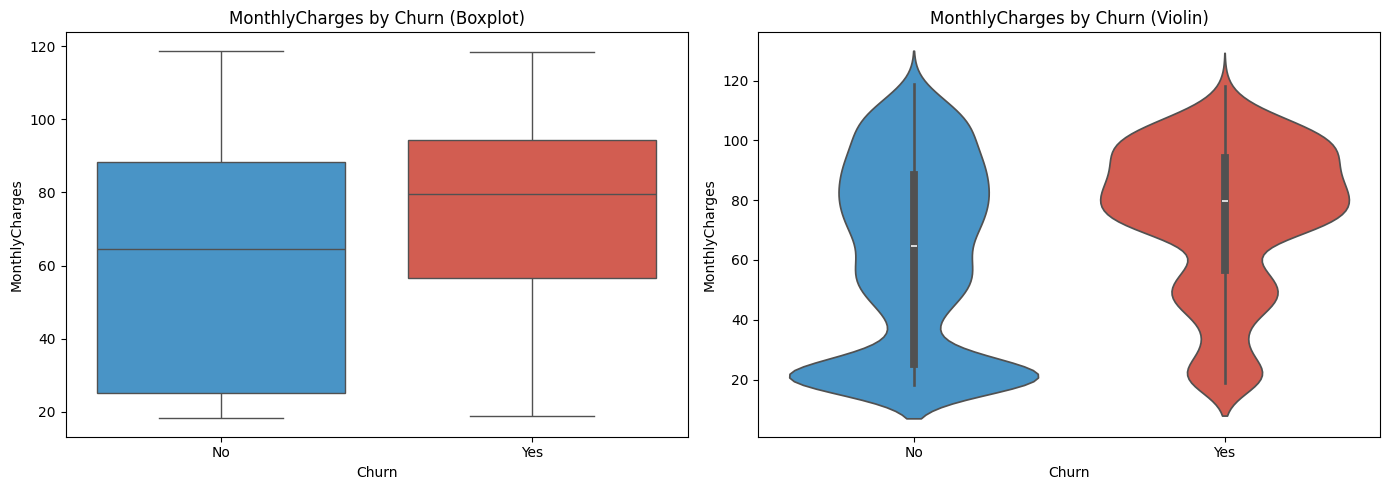

/tmp/ipykernel_5052/11429008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[0], palette=['#3498db', '#e74c3c'])
/tmp/ipykernel_5052/11429008.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y=col, ax=axes[1], palette=['#3498db', '#e74c3c'])


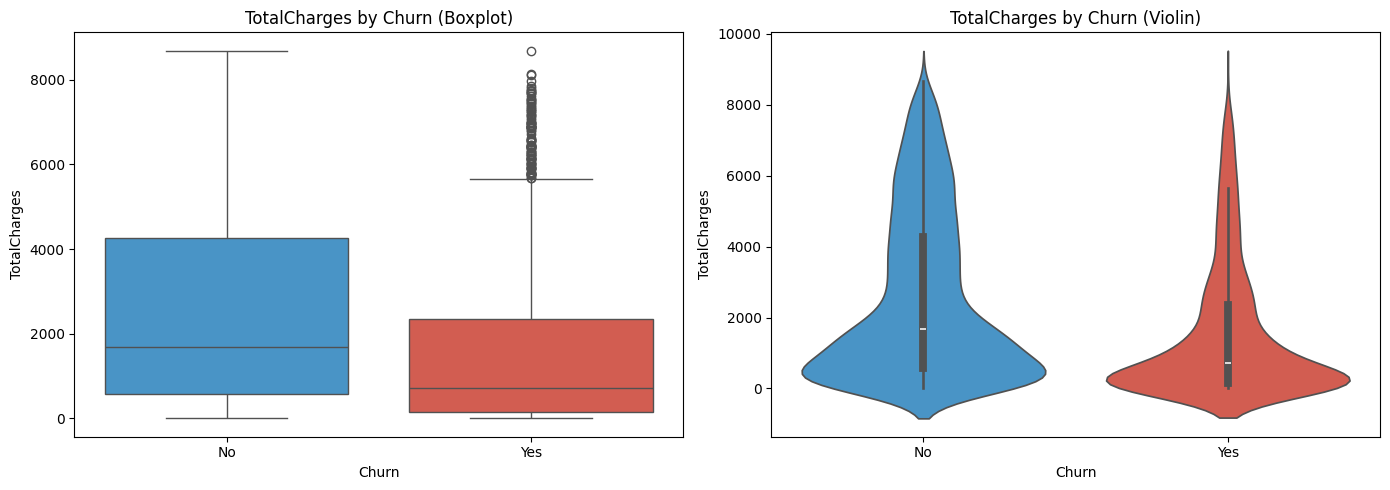

In [155]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(data=df, x='Churn', y=col, ax=axes[0], palette=['#3498db', '#e74c3c'])
    axes[0].set_title(f'{col} by Churn (Boxplot)')

    sns.violinplot(data=df, x='Churn', y=col, ax=axes[1], palette=['#3498db', '#e74c3c'])
    axes[1].set_title(f'{col} by Churn (Violin)')

    plt.tight_layout()
    plt.show()

In [156]:
group_stats = df.groupby('Churn')[num_cols].mean()
group_stats = group_stats.T
group_stats.columns = ['No_Churn_Mean', 'Yes_Churn_Mean']
group_stats['Difference'] = group_stats['Yes_Churn_Mean'] - group_stats['No_Churn_Mean']
print("Mean values by Churn class:")
print(group_stats.round(2))

Mean values by Churn class:
                No_Churn_Mean  Yes_Churn_Mean  Difference
tenure                  37.64           18.09      -19.55
MonthlyCharges          61.34           74.60       13.26
TotalCharges          2554.81         1541.38    -1013.43


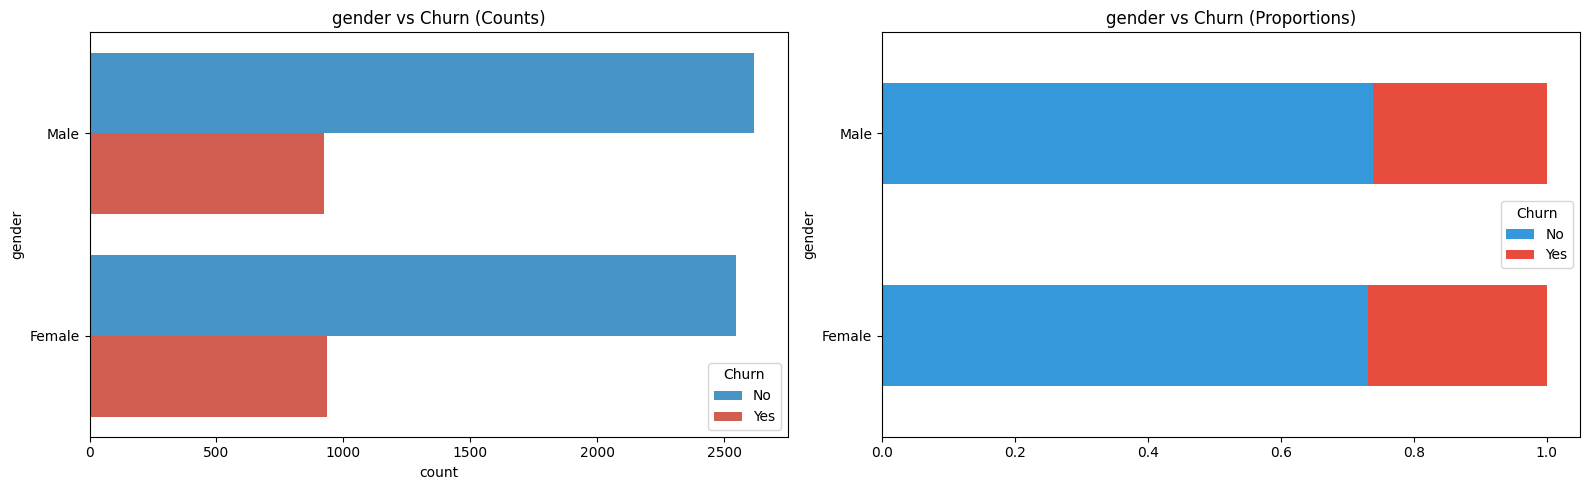

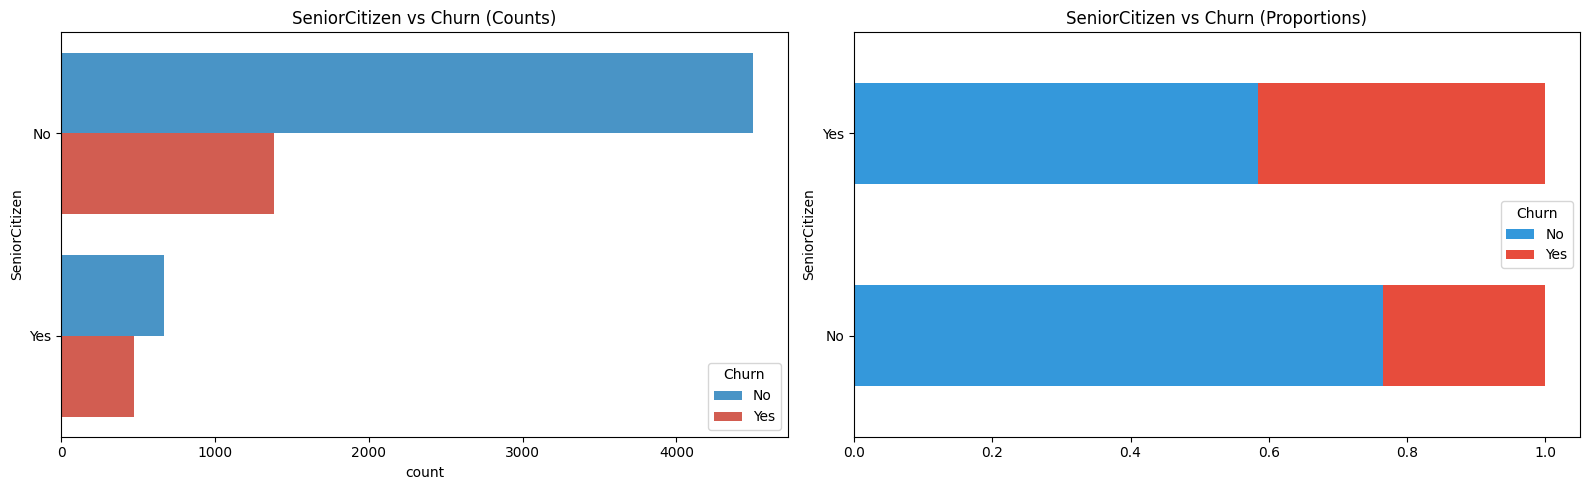

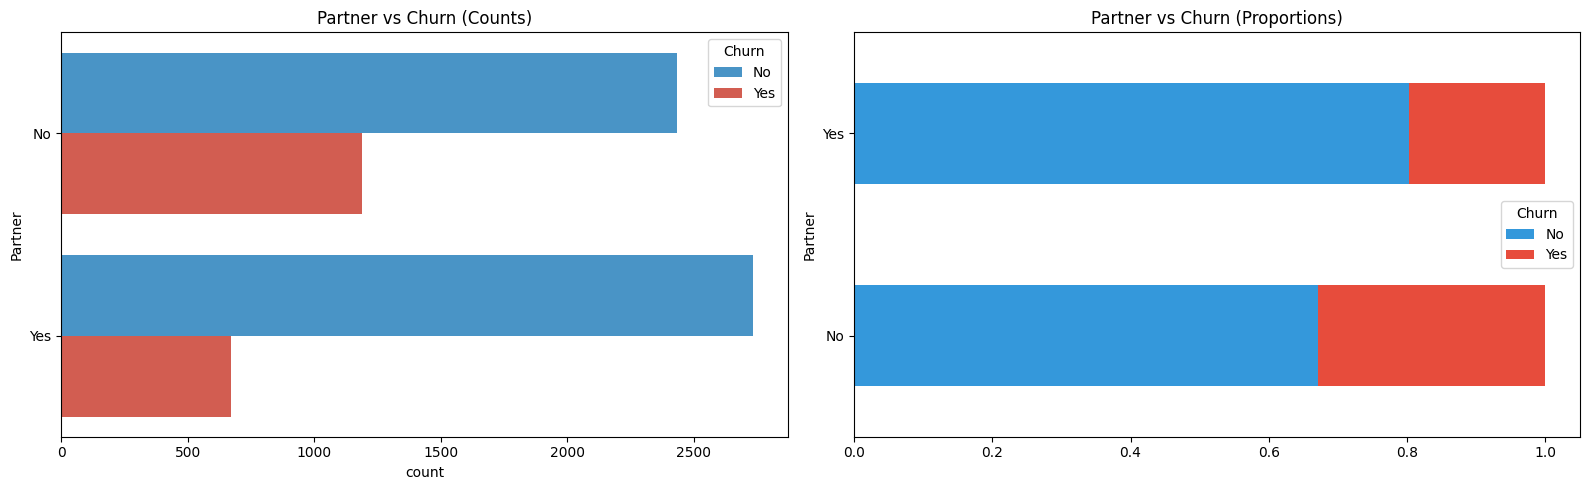

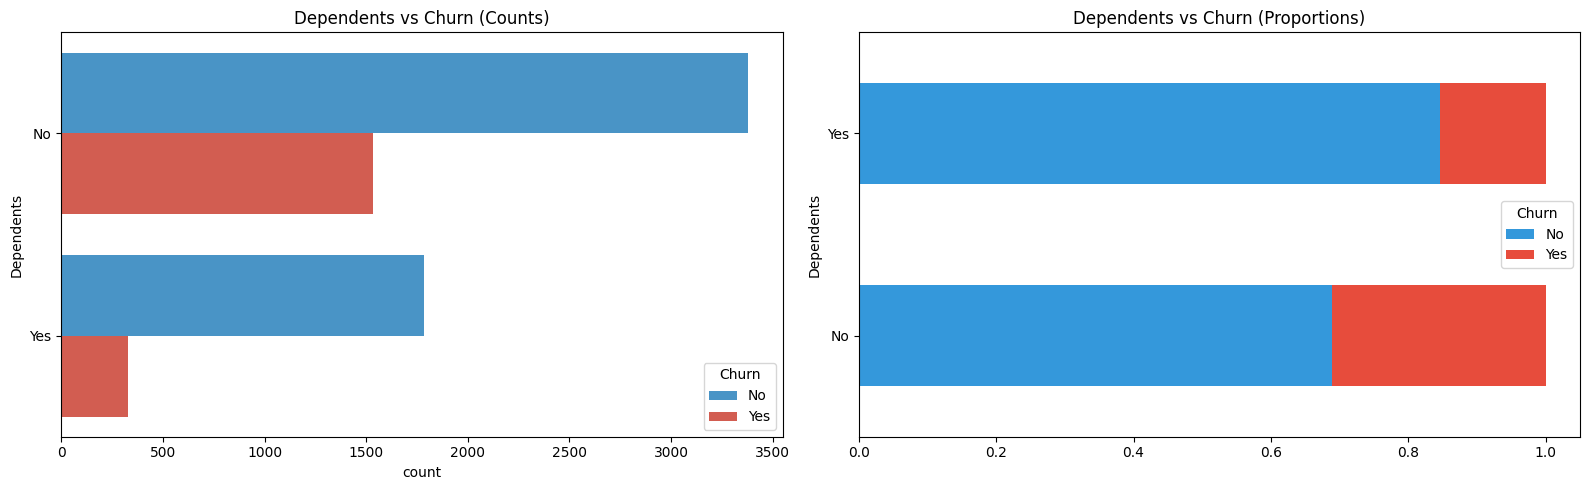

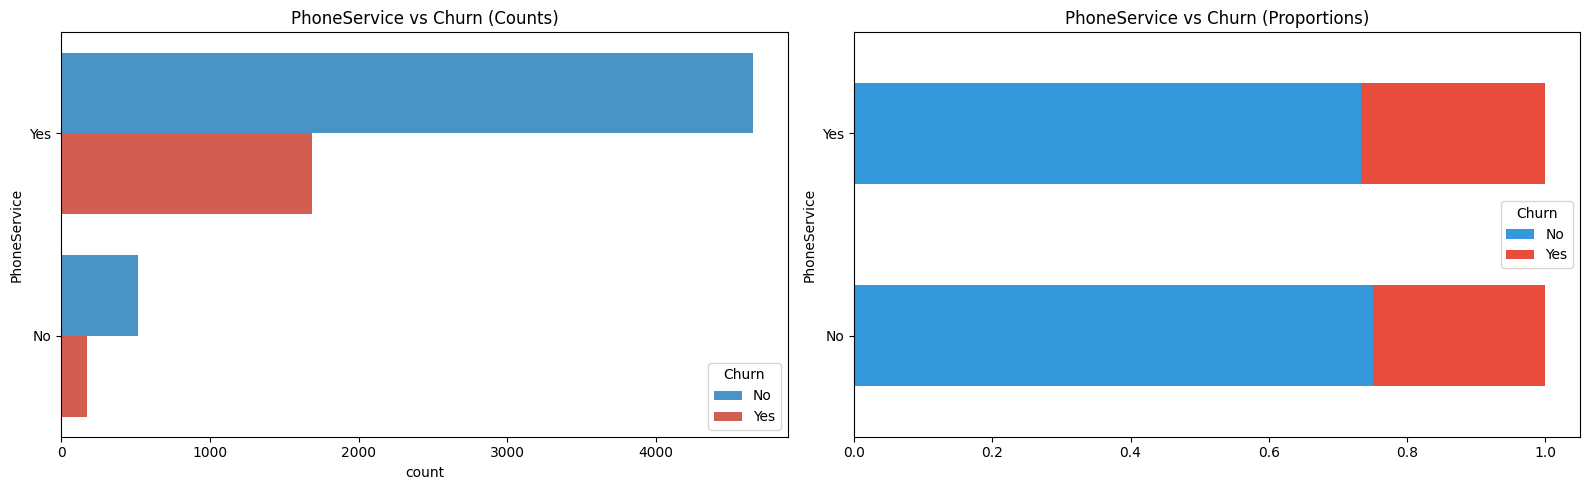

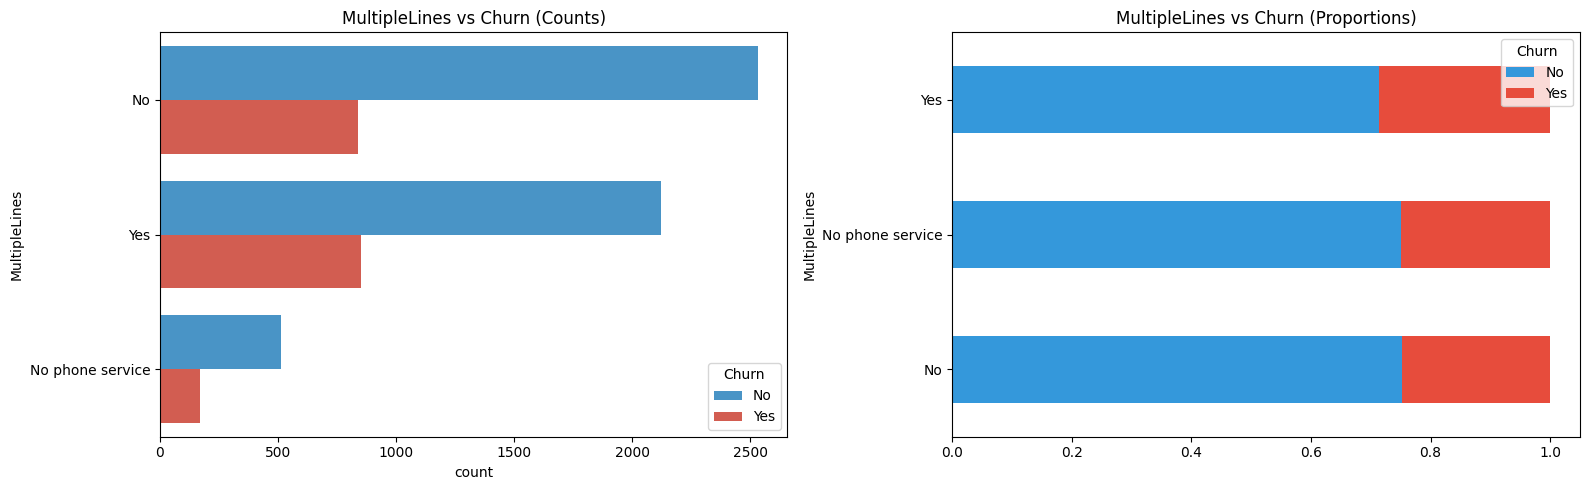

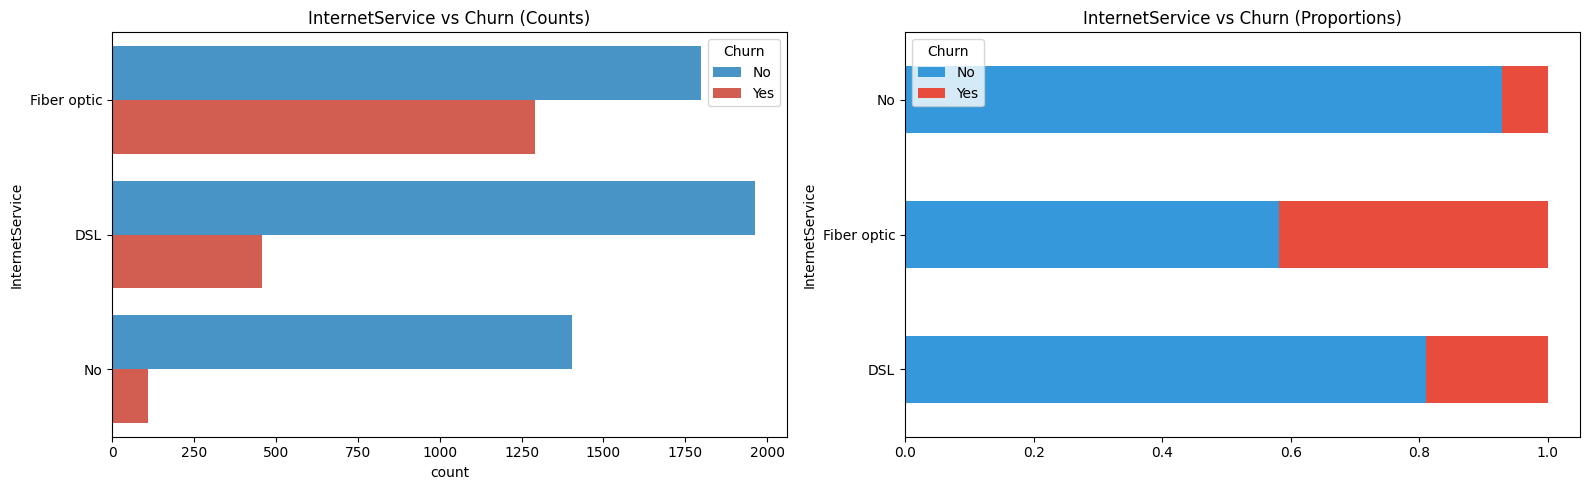

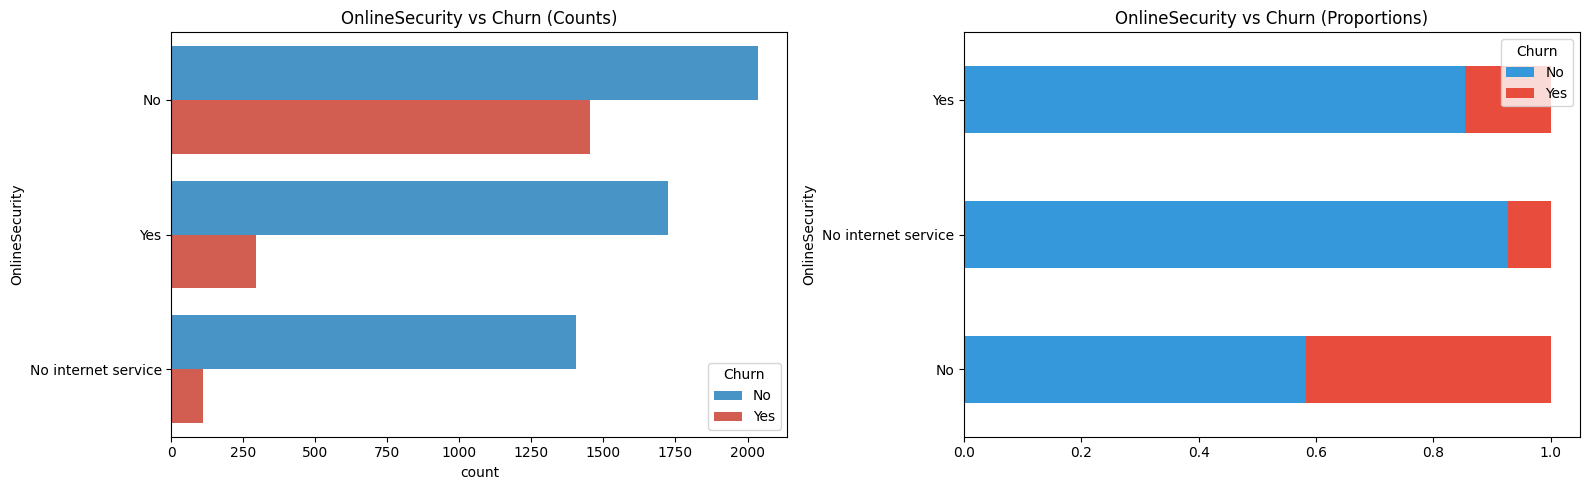

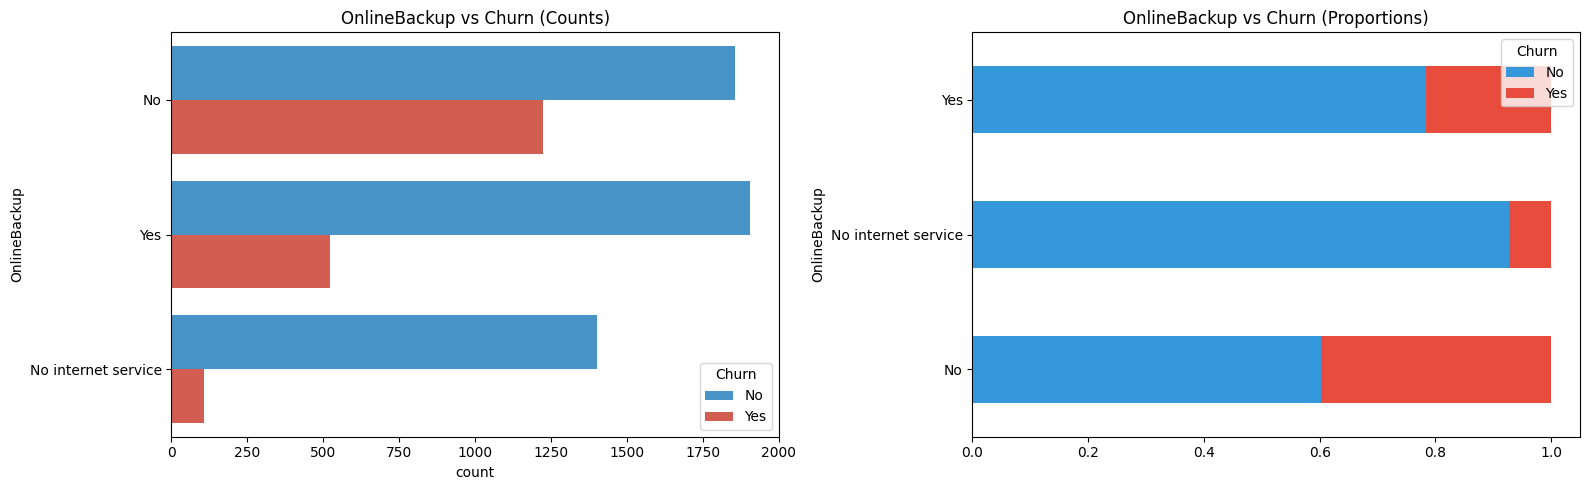

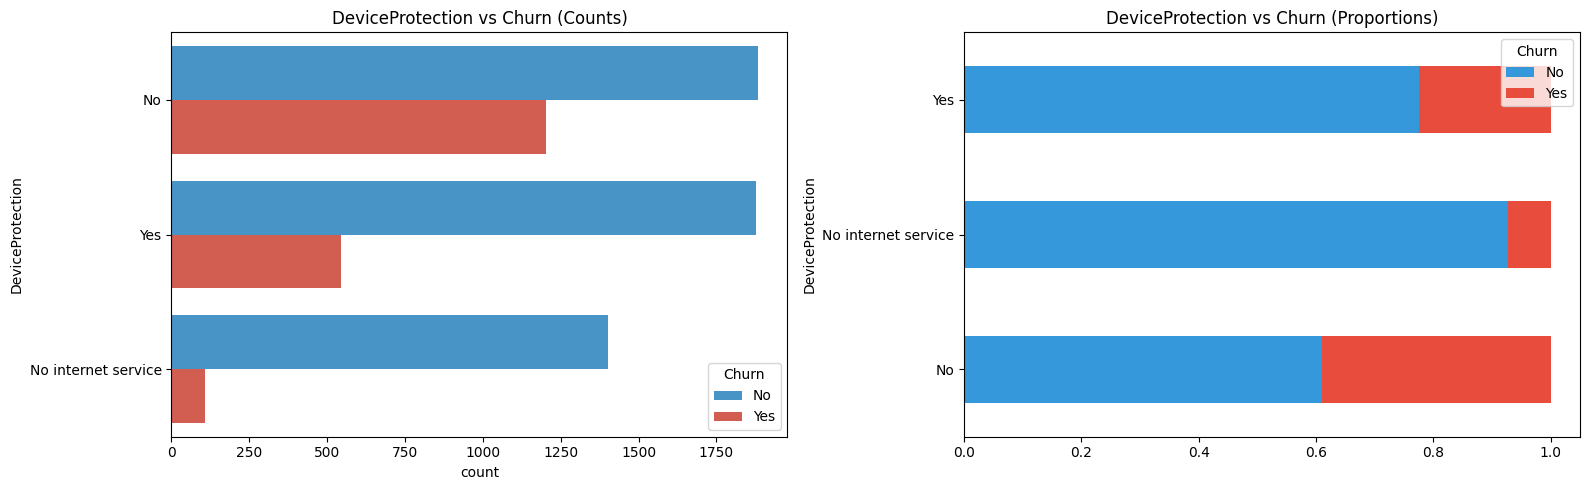

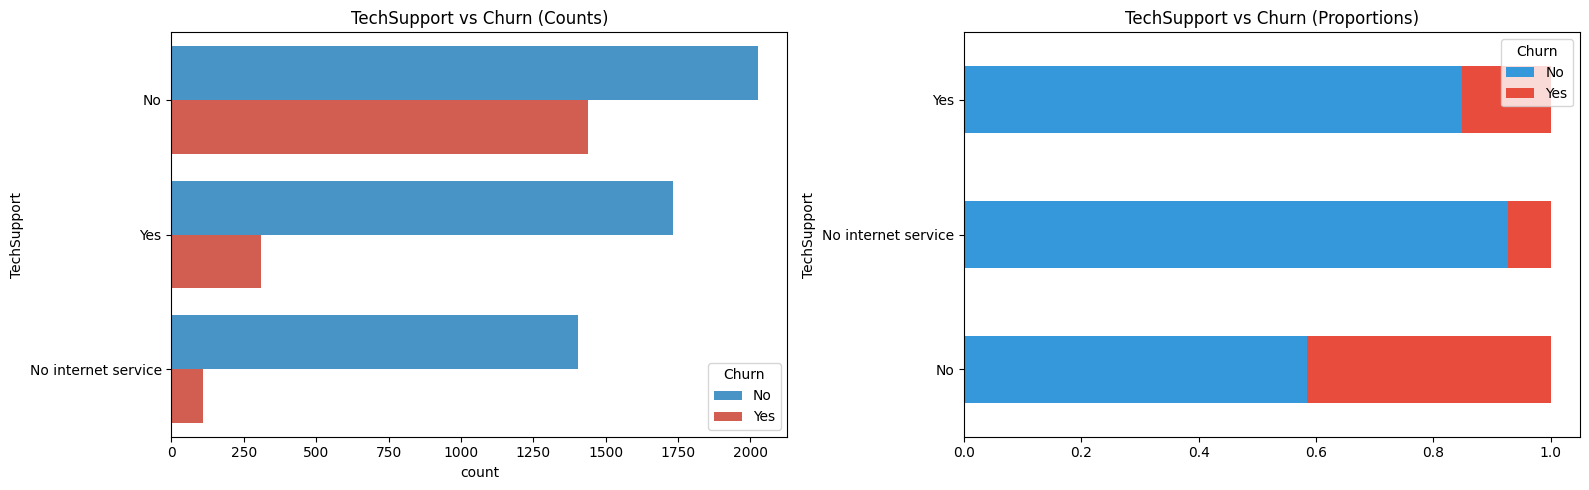

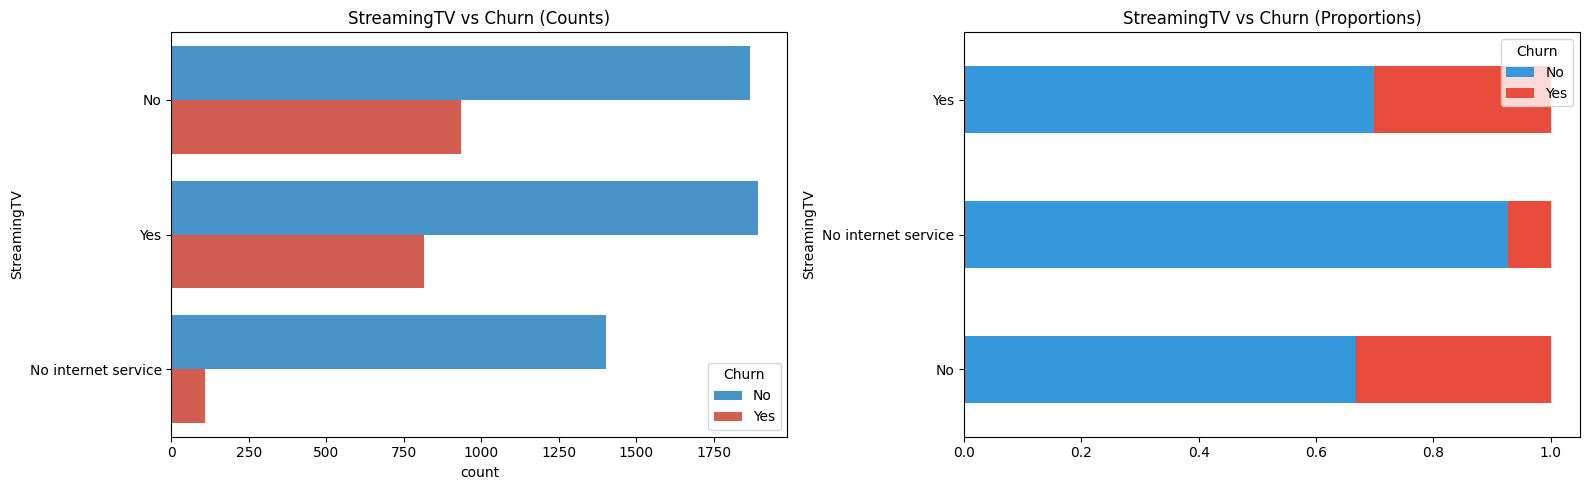

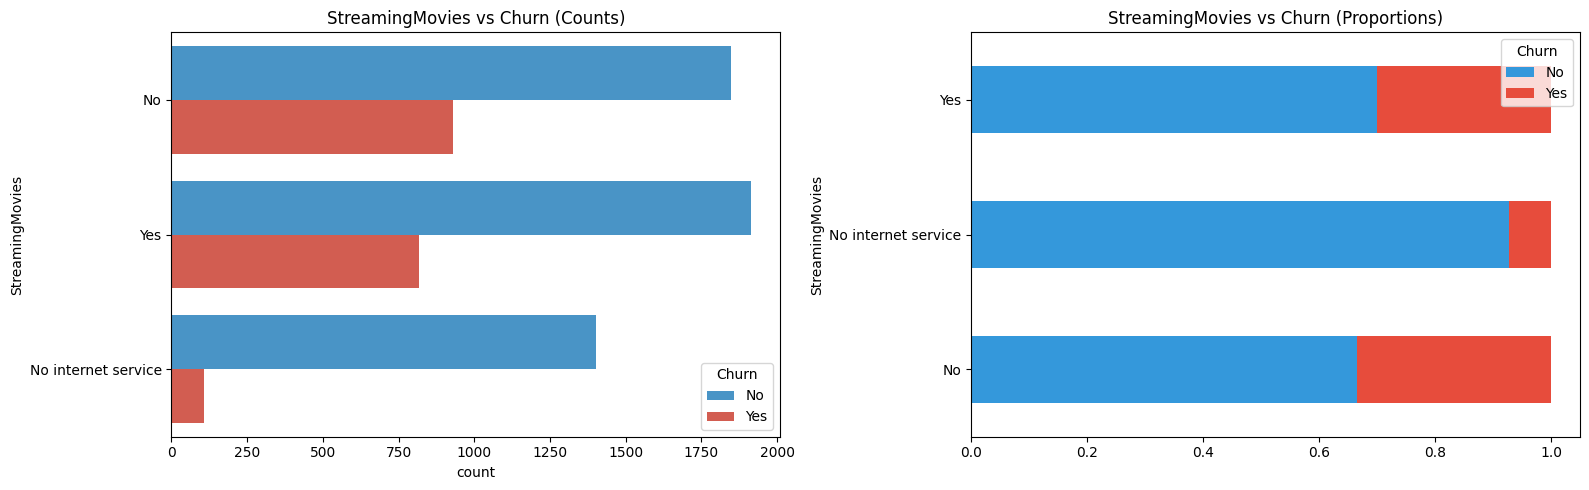

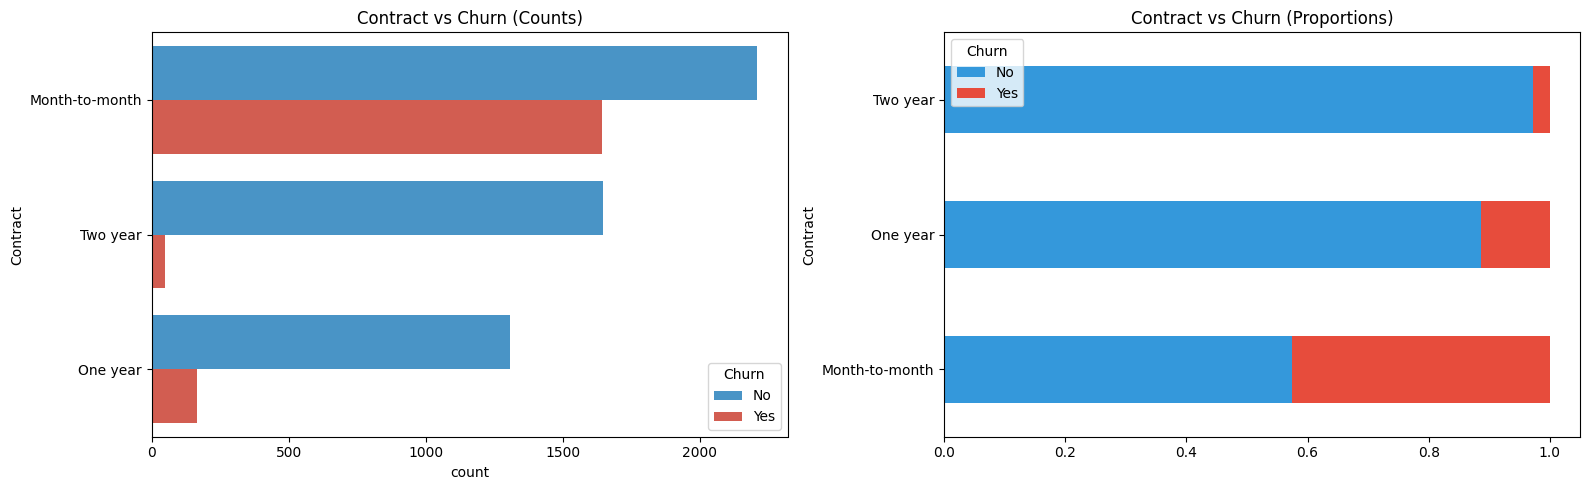

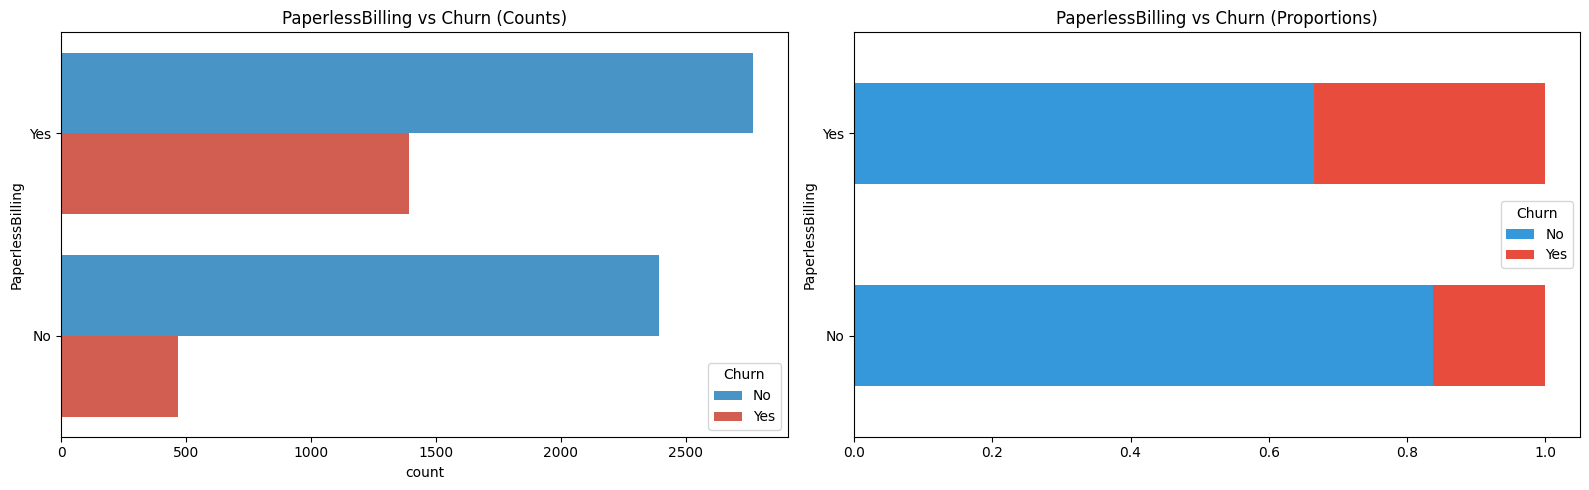

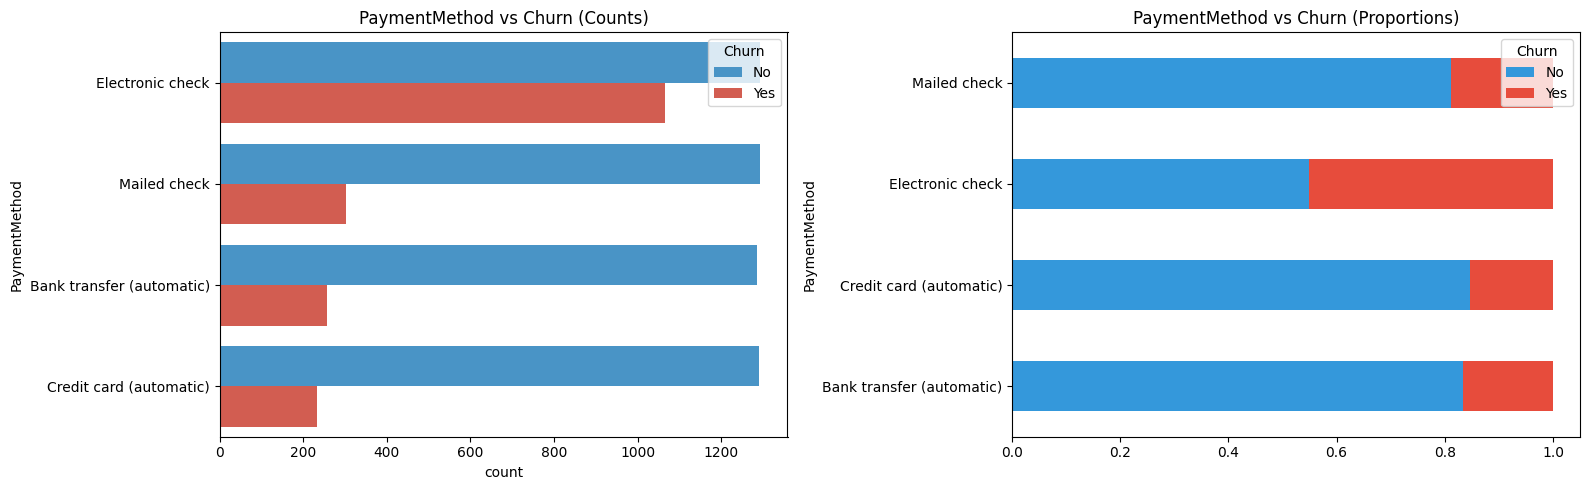

In [157]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue='Churn', order=order, ax=axes[0],
                  palette=['#3498db', '#e74c3c'])
    axes[0].set_title(f'{col} vs Churn (Counts)')

    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='barh', stacked=True, ax=axes[1], color=['#3498db', '#e74c3c'])
    axes[1].set_title(f'{col} vs Churn (Proportions)')
    axes[1].legend(title='Churn')

    plt.tight_layout()
    plt.show()

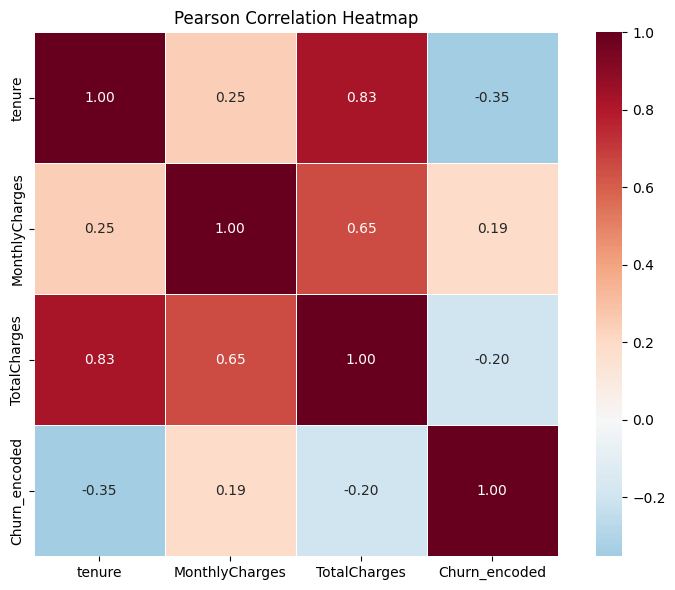

In [158]:
df_corr = df.copy()
df_corr['Churn_encoded'] = (df_corr['Churn'] == 'Yes').astype(int)

corr_cols = num_cols + ['Churn_encoded']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

In [159]:
target_corr = corr_matrix['Churn_encoded'].drop('Churn_encoded').sort_values(ascending=False)
print("Correlation with Churn (Pearson):")
for feat, val in target_corr.items():
    direction = "positive" if val > 0 else "negative"
    print(f"  {feat:20s}: {val:+.3f} ({direction})")

Correlation with Churn (Pearson):
  MonthlyCharges      : +0.195 (positive)
  TotalCharges        : -0.197 (negative)
  tenure              : -0.352 (negative)


In [160]:
print("\nHigh correlation pairs (|r| > 0.7):")
found = False
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        r = corr_matrix.loc[num_cols[i], num_cols[j]]
        if abs(r) > 0.7:
            print(f"  {num_cols[i]} <-> {num_cols[j]}: {r:.3f}")
            found = True
if not found:
    print("  No highly correlated feature pairs found.")


High correlation pairs (|r| > 0.7):
  tenure <-> TotalCharges: 0.826


## Statistical Test

T-Test

In [161]:
print("T-Tests: Numerik vs Churn")
print("=" * 65)

ttest_results = []
for col in num_cols:
    group_no = df[df['Churn'] == 'No'][col]
    group_yes = df[df['Churn'] == 'Yes'][col]
    t_stat, p_val = ttest_ind(group_no, group_yes)
    sig = "Significant" if p_val < 0.05 else "Not Significant"
    ttest_results.append([col, t_stat, p_val, sig])
    print(f"  {col:20s}: t = {t_stat:+8.3f}, p = {p_val:.6f}  -> {sig}")

T-Tests: Numerik vs Churn
  tenure              : t =  +31.457, p = 0.000000  -> Significant
  MonthlyCharges      : t =  -16.613, p = 0.000000  -> Significant
  TotalCharges        : t =  +16.852, p = 0.000000  -> Significant


Chi-square

In [162]:
print("Chi-Square Tests: Categorical vs Churn")
print("=" * 70)

chi2_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p_val, dof, expected = chi2_contingency(ct)
    sig = "Significant" if p_val < 0.05 else "Not Significant"
    chi2_results.append([col, chi2, dof, p_val, sig])
    print(f"  {col:20s}: chi2 = {chi2:10.3f}, dof = {dof}, p = {p_val:.6f}  -> {sig}")

Chi-Square Tests: Categorical vs Churn
  gender              : chi2 =      0.500, dof = 1, p = 0.479462  -> Not Significant
  SeniorCitizen       : chi2 =    160.470, dof = 1, p = 0.000000  -> Significant
  Partner             : chi2 =    155.480, dof = 1, p = 0.000000  -> Significant
  Dependents          : chi2 =    186.786, dof = 1, p = 0.000000  -> Significant
  PhoneService        : chi2 =      0.816, dof = 1, p = 0.366494  -> Not Significant
  MultipleLines       : chi2 =     12.362, dof = 2, p = 0.002069  -> Significant
  InternetService     : chi2 =    732.057, dof = 2, p = 0.000000  -> Significant
  OnlineSecurity      : chi2 =    846.782, dof = 2, p = 0.000000  -> Significant
  OnlineBackup        : chi2 =    598.970, dof = 2, p = 0.000000  -> Significant
  DeviceProtection    : chi2 =    555.884, dof = 2, p = 0.000000  -> Significant
  TechSupport         : chi2 =    824.997, dof = 2, p = 0.000000  -> Significant
  StreamingTV         : chi2 =    374.226, dof = 2, p = 0.0000

In [163]:
print()
print("=" * 70)
print("FULL STATISTICAL TESTS SUMMARY")
print("=" * 70)

print("\nNumerik (T-test):")
print(f"  {'Feature':20s} {'T-stat':>10s} {'p-value':>12s} {'Result':>15s}")
print("  " + "-" * 58)
for row in ttest_results:
    print(f"  {row[0]:20s} {row[1]:+10.3f} {row[2]:12.6f} {row[3]:>15s}")

print("\nCategorical (Chi-Square):")
print(f"  {'Feature':20s} {'Chi2':>10s} {'dof':>5s} {'p-value':>12s} {'Result':>15s}")
print("  " + "-" * 63)
for row in chi2_results:
    print(f"  {row[0]:20s} {row[1]:10.3f} {row[2]:5d} {row[3]:12.6f} {row[4]:>15s}")


FULL STATISTICAL TESTS SUMMARY

Numerik (T-test):
  Feature                  T-stat      p-value          Result
  ----------------------------------------------------------
  tenure                  +31.457     0.000000     Significant
  MonthlyCharges          -16.613     0.000000     Significant
  TotalCharges            +16.852     0.000000     Significant

Categorical (Chi-Square):
  Feature                    Chi2   dof      p-value          Result
  ---------------------------------------------------------------
  gender                    0.500     1     0.479462 Not Significant
  SeniorCitizen           160.470     1     0.000000     Significant
  Partner                 155.480     1     0.000000     Significant
  Dependents              186.786     1     0.000000     Significant
  PhoneService              0.816     1     0.366494 Not Significant
  MultipleLines            12.362     2     0.002069     Significant
  InternetService         732.057     2     0.000000     Sig

## Outlier

In [164]:
print("Outlier Detection: IQR Method")
print("=" * 55)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (outliers / len(df)) * 100
    print(f"  {col:20s}: {outliers:4d} outliers ({pct:.1f}%)  [Range: {lower:.1f} to {upper:.1f}]")

Outlier Detection: IQR Method
  tenure              :    0 outliers (0.0%)  [Range: -60.0 to 124.0]
  MonthlyCharges      :    0 outliers (0.0%)  [Range: -45.5 to 171.1]
  TotalCharges        :    0 outliers (0.0%)  [Range: -4694.2 to 8899.2]


In [165]:
print("Outlier Detection: Z-Score Method (|z| > 3)")
print("=" * 55)
for col in num_cols:
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    outliers = (z_scores.abs() > 3).sum()
    pct = (outliers / len(df)) * 100
    print(f"  {col:20s}: {outliers:4d} outliers ({pct:.1f}%)")

Outlier Detection: Z-Score Method (|z| > 3)
  tenure              :    0 outliers (0.0%)
  MonthlyCharges      :    0 outliers (0.0%)
  TotalCharges        :    0 outliers (0.0%)


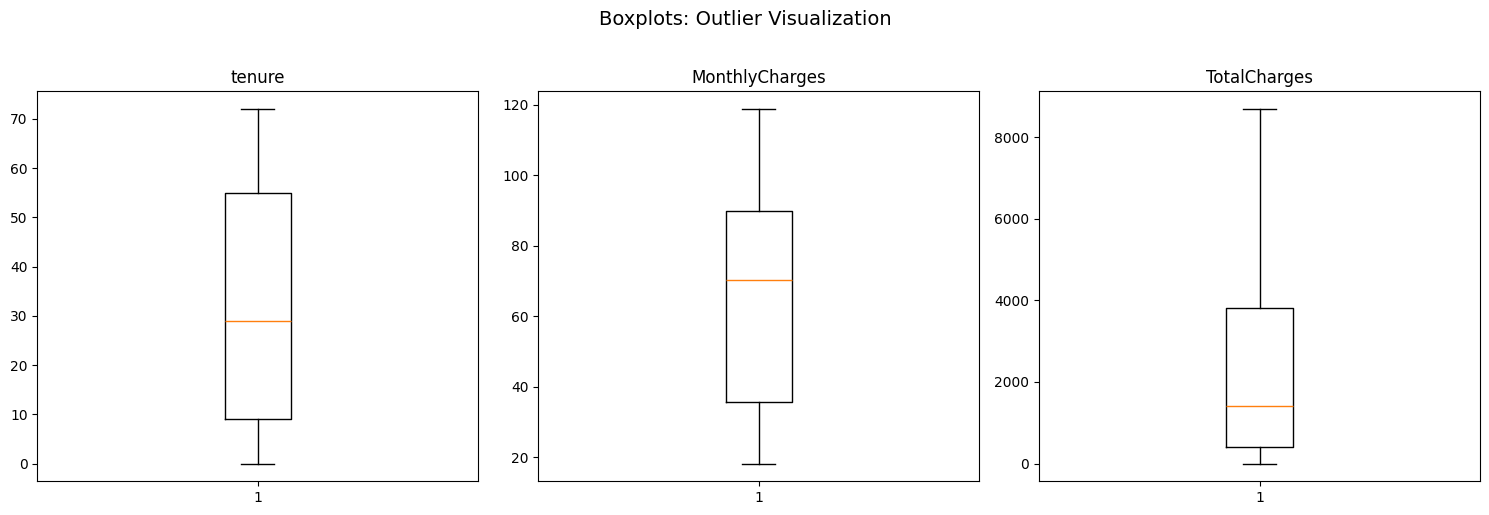

In [166]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)

plt.suptitle('Boxplots: Outlier Visualization', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Skewnees dan Log Transform

Tidak ditemukan fitur/variabel yang distribusinya sangat miring
Perbandingan skew features:


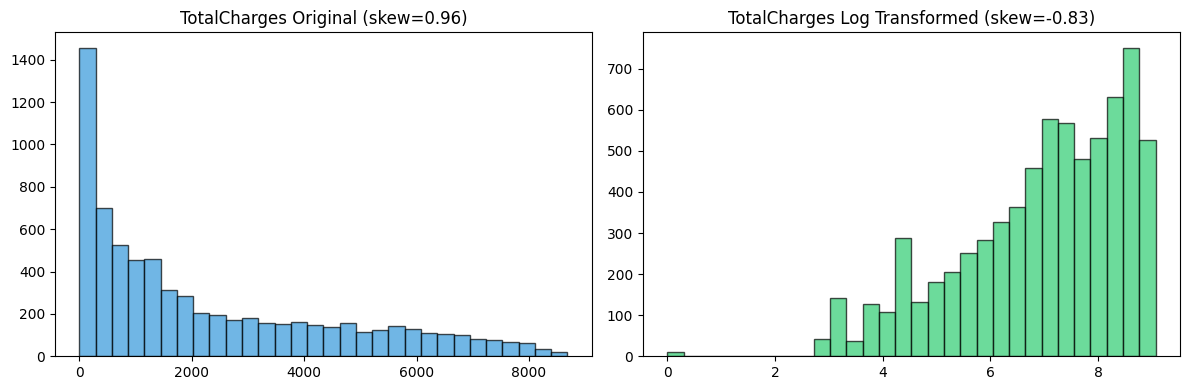

In [167]:
skewed_cols = [col for col in num_cols if abs(df[col].skew()) > 1]

if skewed_cols:
    for col in skewed_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Original
        axes[0].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
        axes[0].set_title(f'{col} Original (skew={df[col].skew():.2f})')

        # Log transformed
        log_vals = np.log1p(df[col])
        axes[1].hist(log_vals, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
        axes[1].set_title(f'{col} Log Transformed (skew={log_vals.skew():.2f})')

        plt.tight_layout()
        plt.show()
else:
    print("Tidak ditemukan fitur/variabel yang distribusinya sangat miring")
    print("Perbandingan skew features:")
    for col in num_cols:
        if abs(df[col].skew()) > 0.3:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            axes[0].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
            axes[0].set_title(f'{col} Original (skew={df[col].skew():.2f})')
            log_vals = np.log1p(df[col])
            axes[1].hist(log_vals, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
            axes[1].set_title(f'{col} Log Transformed (skew={log_vals.skew():.2f})')
            plt.tight_layout()
            plt.show()

## PCA

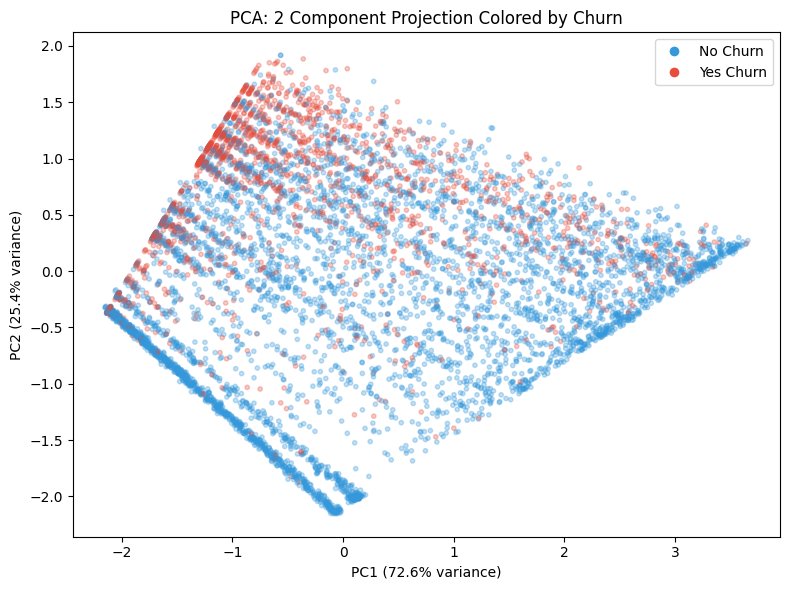

Variance explained by PC1: 72.6%
Variance explained by PC2: 25.4%
Total variance explained: 98.0%


In [168]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = ['#3498db' if c == 'No' else '#e74c3c' for c in df['Churn']]
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.3, s=10)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA: 2 Component Projection Colored by Churn')

from matplotlib.lines import Line2D
legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', label='No Churn', markersize=8),
          Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', label='Yes Churn', markersize=8)]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Feature Engineering

In [169]:
unseen_raw, df = train_test_split(df, test_size=0.98, random_state=99, stratify=df['Churn'])

print(f"Unseen samples  : {len(unseen_raw)}")
print(f"Data modelling  : {len(df)}")

Unseen samples  : 140
Data modelling  : 6881


In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6881 entries, 550 to 1674
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6881 non-null   object 
 1   SeniorCitizen     6881 non-null   object 
 2   Partner           6881 non-null   object 
 3   Dependents        6881 non-null   object 
 4   tenure            6881 non-null   int64  
 5   PhoneService      6881 non-null   object 
 6   MultipleLines     6881 non-null   object 
 7   InternetService   6881 non-null   object 
 8   OnlineSecurity    6881 non-null   object 
 9   OnlineBackup      6881 non-null   object 
 10  DeviceProtection  6881 non-null   object 
 11  TechSupport       6881 non-null   object 
 12  StreamingTV       6881 non-null   object 
 13  StreamingMovies   6881 non-null   object 
 14  Contract          6881 non-null   object 
 15  PaperlessBilling  6881 non-null   object 
 16  PaymentMethod     6881 non-null   object 
 17

In [171]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

gender: ['Male' 'Female']
SeniorCitizen: ['No' 'Yes']
Partner: ['Yes' 'No']
Dependents: ['Yes' 'No']
tenure: [72 45 18  9  3  5 65  8 63 22 13 71 19 60 24 16 35 40 64 68  1 54  7 12
 51 56 15 52  2 49 50 57 32 39 47 58 30 23 53 28  6 42 67  4 20 69 25 55
 41 70 27 59 34 36 44 48 10 46 66 62 29 33 61 11 43 21  0 38 17 26 14 31
 37]
PhoneService: ['Yes' 'No']
MultipleLines: ['Yes' 'No' 'No phone service']
InternetService: ['Fiber optic' 'DSL' 'No']
OnlineSecurity: ['Yes' 'No' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['Yes' 'No' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['Yes' 'No' 'No internet service']
StreamingMovies: ['Yes' 'No' 'No internet service']
Contract: ['Two year' 'Month-to-month' 'One year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Bank transfer (automatic)' 'Electronic check' 'Mailed check'
 'Credit card (automatic)']
MonthlyCharges: [110.3  105.15  83.25 ... 101.85  52.    29.

In [172]:
binary_map = {
    'gender':           {'Female': 0, 'Male': 1},
    'SeniorCitizen':    {'No': 0, 'Yes': 1},
    'Partner':          {'No': 0, 'Yes': 1},
    'Dependents':       {'No': 0, 'Yes': 1},
    'PhoneService':     {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1},
    'Churn':            {'No': 0, 'Yes': 1},
}
for col, mapping in binary_map.items():
    df[col] = df[col].map(mapping)

df['MultipleLines'] = df['MultipleLines'].map({
    'No phone service': 0,
    'No': 0,
    'Yes': 1
})

internet_addon_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
addon_map = {'No internet service': 0, 'No': 0, 'Yes': 1}
for col in internet_addon_cols:
    df[col] = df[col].map(addon_map)

df['Contract'] = df['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

df = pd.get_dummies(df, columns=['InternetService', 'PaymentMethod'], dtype=int)

print(df.dtypes)
print(df.head())

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
Contract                                     int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                          int64
InternetService_Fiber optic    

In [173]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
550,1,0,1,1,72,1,1,1,1,1,...,110.30,7966.90,0,0,1,0,1,0,0,0
1246,0,0,1,1,45,1,1,1,1,0,...,105.15,4730.90,0,0,1,0,0,0,1,0
5737,1,0,1,1,18,1,0,1,0,1,...,83.25,1611.15,0,1,0,0,0,0,1,0
2433,1,0,0,0,9,0,0,1,0,1,...,50.80,463.60,0,1,0,0,0,0,0,1
3960,0,0,0,0,3,1,0,0,0,1,...,57.55,161.45,0,1,0,0,0,0,1,0


In [174]:
services = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies']

df['TotalServices'] = df[services].sum(axis=1)

df['ChargePerService'] = df['MonthlyCharges'] / (df['TotalServices'] + 1)

df['AvgCharges'] = df.apply(
    lambda r: r['TotalCharges'] / r['tenure'] if r['tenure'] > 0 else r['MonthlyCharges'],
    axis=1
)

df['IsNewCustomer'] = (df['tenure'] <= 3).astype(int)  # <= 3 bulan = pelanggan baru

df['IsLongTerm'] = (df['Contract'] != 0).astype(int)

df['TenureGroup'] = pd.cut(
    df['tenure'], bins=[-1, 12, 24, 48, 72],
    labels=[0, 1, 2, 3]
).astype(int)

# Modeling

In [175]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [176]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=scale_pos, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [177]:
for name, model in [('Random Forest', rf), ('XGBoost', xgb)]:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{'='*40}")
    print(f"{name}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


Random Forest
              precision    recall  f1-score   support

    No Churn       0.82      0.91      0.86      1013
       Churn       0.64      0.46      0.54       364

    accuracy                           0.79      1377
   macro avg       0.73      0.68      0.70      1377
weighted avg       0.78      0.79      0.78      1377

ROC-AUC: 0.8276

XGBoost
              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.83      1013
       Churn       0.54      0.64      0.59       364

    accuracy                           0.76      1377
   macro avg       0.70      0.72      0.71      1377
weighted avg       0.78      0.76      0.77      1377

ROC-AUC: 0.8183


# Tuning

In [178]:
thresholds = np.arange(0.20, 0.70, 0.01)
best_thresholds = {}

y_proba_rf  = rf.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

for name, y_proba in [('Random Forest', y_proba_rf), ('XGBoost', y_proba_xgb)]:
    best_t, best_f1 = 0, 0
    for t in thresholds:
        f1 = f1_score(y_test, (y_proba > t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresholds[name] = best_t  # simpan otomatis
    print(f"{name} → Best Threshold: {best_t:.2f} | F1: {best_f1:.4f}")


models = {'Random Forest': rf, 'XGBoost': xgb}

for name, model in models.items():
    t = best_thresholds[name]
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba > t).astype(int)

    print(f"\n{'='*40}")
    print(f"{name} (threshold={t})")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Random Forest → Best Threshold: 0.21 | F1: 0.6095
XGBoost → Best Threshold: 0.31 | F1: 0.6043

Random Forest (threshold=0.21000000000000002)
              precision    recall  f1-score   support

    No Churn       0.91      0.69      0.79      1013
       Churn       0.49      0.81      0.61       364

    accuracy                           0.73      1377
   macro avg       0.70      0.75      0.70      1377
weighted avg       0.80      0.73      0.74      1377

ROC-AUC: 0.8276

XGBoost (threshold=0.3100000000000001)
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.79      1013
       Churn       0.49      0.78      0.60       364

    accuracy                           0.73      1377
   macro avg       0.70      0.75      0.70      1377
weighted avg       0.79      0.73      0.74      1377

ROC-AUC: 0.8183


In [179]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': 'balanced',
        'random_state': 42,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1').mean()
    return score

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
        'eval_metric': 'logloss',
        'random_state': 42,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1').mean()
    return score

print("Tuning Random Forest...")
study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=False)

print("\nTuning XGBoost...")
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=False)

print(f"\nBest RF  F1: {study_rf.best_value:.4f} | Params: {study_rf.best_params}")
print(f"Best XGB F1: {study_xgb.best_value:.4f} | Params: {study_xgb.best_params}")

[I 2026-05-01 02:13:48,632] A new study created in memory with name: no-name-15ee6fb8-aacd-4ac3-a5ed-35eebb9f1e0c


Tuning Random Forest...


[I 2026-05-01 02:13:56,941] Trial 0 finished with value: 0.6367386905510766 and parameters: {'n_estimators': 250, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6367386905510766.
[I 2026-05-01 02:14:00,887] Trial 1 finished with value: 0.6378846277312399 and parameters: {'n_estimators': 123, 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 1 with value: 0.6378846277312399.
[I 2026-05-01 02:14:09,430] Trial 2 finished with value: 0.6259855223914679 and parameters: {'n_estimators': 433, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 0.6378846277312399.
[I 2026-05-01 02:14:15,924] Trial 3 finished with value: 0.6319200746816905 and parameters: {'n_estimators': 273, 'max_depth': 6, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 0.6378846277312


Tuning XGBoost...


[I 2026-05-01 02:16:10,152] Trial 0 finished with value: 0.5773041414485244 and parameters: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.14907884894416698, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 1.5599452033620265, 'reg_lambda': 1.5227525095137953}. Best is trial 0 with value: 0.5773041414485244.
[I 2026-05-01 02:16:13,952] Trial 1 finished with value: 0.6081508663423738 and parameters: {'n_estimators': 447, 'max_depth': 6, 'learning_rate': 0.14453378978124864, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'reg_alpha': 8.324426408004218, 'reg_lambda': 2.9110519961044856}. Best is trial 1 with value: 0.6081508663423738.
[I 2026-05-01 02:16:15,019] Trial 2 finished with value: 0.6322978506302207 and parameters: {'n_estimators': 172, 'max_depth': 4, 'learning_rate': 0.06780602616231217, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'reg_alpha': 2.9122914019804194, 'reg_lambda': 


Best RF  F1: 0.6382 | Params: {'n_estimators': 214, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}
Best XGB F1: 0.6347 | Params: {'n_estimators': 424, 'max_depth': 4, 'learning_rate': 0.028557701661212936, 'subsample': 0.8736932106048627, 'colsample_bytree': 0.7760609974958406, 'reg_alpha': 1.2203823484477883, 'reg_lambda': 5.456592191001432}


In [180]:
rf_tuned = RandomForestClassifier(
    **study_rf.best_params,
    class_weight='balanced',
    random_state=42
)
rf_tuned.fit(X_train, y_train)

xgb_tuned = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)
xgb_tuned.fit(X_train, y_train)

thresholds = np.arange(0.20, 0.70, 0.01)
best_thresholds_tuned = {}
for name, model in [('Random Forest Tuned', rf_tuned), ('XGBoost Tuned', xgb_tuned)]:
    y_proba = model.predict_proba(X_test)[:, 1]
    best_t, best_f1 = 0, 0
    for t in thresholds:
        f1 = f1_score(y_test, (y_proba > t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t

    best_thresholds_tuned[name] = best_t

    y_pred = (y_proba > best_t).astype(int)
    print(f"\n{'='*40}")
    print(f"{name} (threshold={best_t:.2f})")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
    print(f"Best F1  : {best_f1:.4f}")


Random Forest Tuned (threshold=0.51)
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1013
       Churn       0.56      0.74      0.63       364

    accuracy                           0.77      1377
   macro avg       0.72      0.76      0.74      1377
weighted avg       0.80      0.77      0.78      1377

ROC-AUC : 0.8454
Best F1  : 0.6344

XGBoost Tuned (threshold=0.57)
              precision    recall  f1-score   support

    No Churn       0.89      0.80      0.85      1013
       Churn       0.57      0.73      0.64       364

    accuracy                           0.78      1377
   macro avg       0.73      0.77      0.74      1377
weighted avg       0.81      0.78      0.79      1377

ROC-AUC : 0.8486
Best F1  : 0.6409


In [181]:
print("=" * 55)
print(f"{'Model':<20} {'Train F1':>10} {'Test F1':>10} {'Gap':>8}")
print("=" * 55)

for name, model in [('Random Forest', rf_tuned), ('XGBoost', xgb_tuned)]:
    y_train_pred = model.predict(X_train)
    train_f1 = f1_score(y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    test_f1 = f1_score(y_test, y_test_pred)

    gap = train_f1 - test_f1
    status = "Overfit" if gap > 0.1 else "Aman"

    print(f"{name:<20} {train_f1:>10.4f} {test_f1:>10.4f} {gap:>7.4f}  {status}")

Model                  Train F1    Test F1      Gap
Random Forest            0.6966     0.6321  0.0646  Aman
XGBoost                  0.6907     0.6310  0.0597  Aman


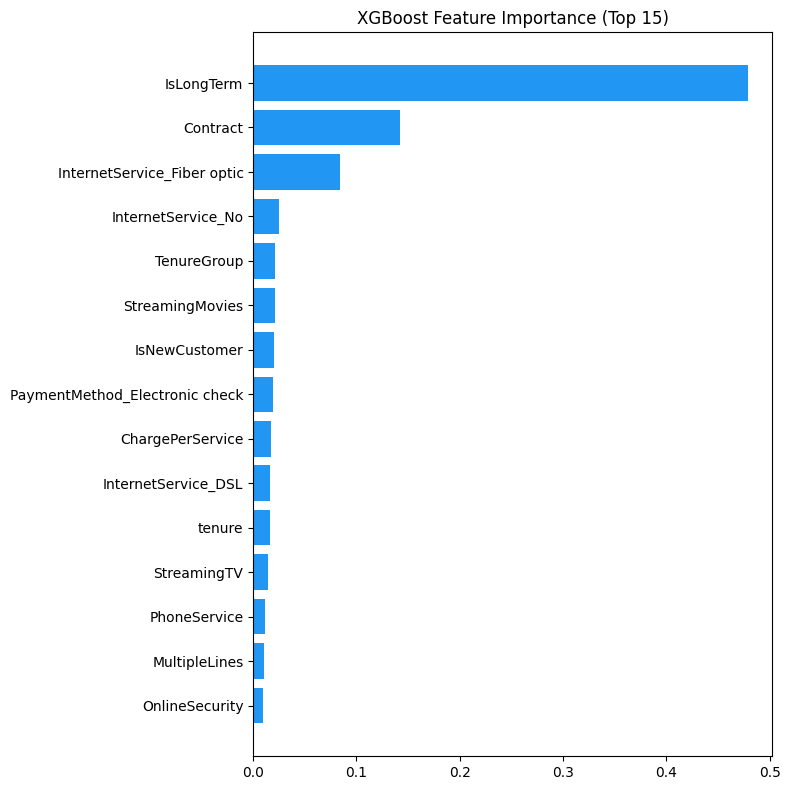

In [182]:
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_tuned.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(8, 8))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='#2196F3')
plt.title('XGBoost Feature Importance (Top 15)')
plt.tight_layout()
plt.show()

Mencoba SMOTE

In [183]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Sebelum SMOTE : {y_train.value_counts().to_dict()}")
print(f"Sesudah SMOTE : {pd.Series(y_train_sm).value_counts().to_dict()}")

rf_smote = RandomForestClassifier(
    **study_rf.best_params,
    class_weight='balanced',
    random_state=42
)
rf_smote.fit(X_train_sm, y_train_sm)

xgb_smote = XGBClassifier(
    **study_xgb.best_params,
    eval_metric='logloss',
    random_state=42
)
xgb_smote.fit(X_train_sm, y_train_sm)

thresholds = np.arange(0.20, 0.70, 0.01)

for name, model in [('RF + SMOTE', rf_smote), ('XGBoost + SMOTE', xgb_smote)]:
    y_proba = model.predict_proba(X_test)[:, 1]
    best_t, best_f1 = 0, 0
    for t in thresholds:
        f1 = f1_score(y_test, (y_proba > t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t

    y_pred = (y_proba > best_t).astype(int)
    print(f"\n{'='*40}")
    print(f"{name} (threshold={best_t:.2f})")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
    print(f"Best F1  : {best_f1:.4f}")

Sebelum SMOTE : {0: 4048, 1: 1456}
Sesudah SMOTE : {1: 4048, 0: 4048}

RF + SMOTE (threshold=0.45)
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82      1013
       Churn       0.53      0.77      0.63       364

    accuracy                           0.76      1377
   macro avg       0.72      0.77      0.73      1377
weighted avg       0.81      0.76      0.77      1377

ROC-AUC : 0.8375
Best F1  : 0.6323

XGBoost + SMOTE (threshold=0.36)
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1013
       Churn       0.53      0.78      0.63       364

    accuracy                           0.76      1377
   macro avg       0.72      0.76      0.73      1377
weighted avg       0.80      0.76      0.77      1377

ROC-AUC : 0.8372
Best F1  : 0.6296


# Save Model

In [184]:
joblib.dump(xgb_tuned, 'xgb_churn_model.pkl')
metadata = {
    'features': X.columns.tolist(),
    'threshold': best_thresholds_tuned['XGBoost Tuned'],
    'best_cv_f1': study_xgb.best_value,
    'best_params': study_xgb.best_params,
}
joblib.dump(metadata, 'xgb_churn_metadata.pkl')

print("Model tersimpan: xgb_churn_model.pkl")
print("Metadata tersimpan: xgb_churn_metadata.pkl")

Model tersimpan: xgb_churn_model.pkl
Metadata tersimpan: xgb_churn_metadata.pkl


# Inference Script

In [185]:
unseen = unseen_raw.copy()

# Encoding
binary_map = {
    'gender': {'Female': 0, 'Male': 1},
    'SeniorCitizen': {'No': 0, 'Yes': 1},
    'Partner': {'No': 0, 'Yes': 1},
    'Dependents': {'No': 0, 'Yes': 1},
    'PhoneService': {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1},
    'Churn': {'No': 0, 'Yes': 1},
}
for col, mapping in binary_map.items():
    unseen[col] = unseen[col].map(mapping)

unseen['MultipleLines'] = unseen['MultipleLines'].map({'No phone service': 0, 'No': 0, 'Yes': 1})
for col in ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']:
    unseen[col] = unseen[col].map({'No internet service': 0, 'No': 0, 'Yes': 1})
unseen['Contract'] = unseen['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
unseen = pd.get_dummies(unseen, columns=['InternetService', 'PaymentMethod'], dtype=int)

# Feature engineering
services = ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
unseen['TotalServices']    = unseen[services].sum(axis=1)
unseen['ChargePerService'] = unseen['MonthlyCharges'] / (unseen['TotalServices'] + 1)
unseen['AvgCharges']       = unseen.apply(
    lambda r: r['TotalCharges'] / r['tenure'] if r['tenure'] > 0 else r['MonthlyCharges'], axis=1)
unseen['IsNewCustomer']    = (unseen['tenure'] <= 3).astype(int)
unseen['IsLongTerm']       = (unseen['Contract'] != 0).astype(int)
unseen['TenureGroup']      = pd.cut(unseen['tenure'], bins=[-1,12,24,48,72], labels=[0,1,2,3]).astype(int)

unseen_X = unseen[X.columns]
unseen_y = unseen['Churn']

random.seed(42)
indices = random.sample(range(len(unseen_X)), 10)
threshold = best_thresholds_tuned['XGBoost Tuned']

results = []
for idx in indices:
    proba = xgb_tuned.predict_proba(unseen_X.iloc[[idx]])[:, 1][0]
    pred = "Churn" if proba > threshold else "No Churn"
    actual = "Churn" if unseen_y.iloc[idx] == 1 else "No Churn"
    results.append({
        'Confidence Score': f"{proba:.2%}",
        'Prediksi':         pred,
        'Aktual':           actual,
        'Hasil':            'Benar' if pred == actual else 'Salah'
    })

results_df = pd.DataFrame(results, index=range(1, 11))
results_df.index.name = 'No'
print(results_df.to_string())

results_df.to_csv('inference_results.csv', index=True)
print("\nHasil disimpan: inference_results.csv")

   Confidence Score  Prediksi    Aktual  Hasil
No                                            
1             9.97%  No Churn  No Churn  Benar
2            75.89%     Churn     Churn  Benar
3            22.31%  No Churn  No Churn  Benar
4            82.47%     Churn     Churn  Benar
5            86.31%     Churn     Churn  Benar
6             4.79%  No Churn  No Churn  Benar
7            22.89%  No Churn  No Churn  Benar
8            79.22%     Churn  No Churn  Salah
9            27.49%  No Churn  No Churn  Benar
10           27.15%  No Churn  No Churn  Benar

Hasil disimpan: inference_results.csv


# Summary

## Dataset:
1. Data diambil dari kaggle : https://www.kaggle.com/datasets/blastchar/telco-customer-churn

2. Dari df.info() terlihat bahwa kolom TotalCharges mencurigakan karena bertipe object (string) padahal seharusnya float64, yang menandakan adanya nilai non-numerik seperti spasi atau karakter khusus; sementara itu MonthlyCharges sudah benar bertipe float64, serta tenure dan SeniorCitizen bertipe int64, dan customerID hanya merupakan ID unik tanpa nilai prediktif sehingga akan dihapus.
---

<br>
<br>

## Target:

Sekitar 73% pelanggan tidak melakukan churn dan 27% melakukan churn, sehingga perbandingannya sekitar 2,7:1. Ini termasuk ketidakseimbangan data yang sedang, tidak terlalu parah tetapi cukup berpengaruh pada performa model jika hanya melihat akurasi. Misalnya, model yang selalu memprediksi “tidak churn” bisa mendapatkan akurasi 73% tanpa benar-benar belajar pola yang berguna.

---
<br>
<br>

## Analysis
Berdasarkan analisis yang saya lakukan, saya memilih model berbasis Tree seperti XGBoost dan Random Forest. PCA menunjukkan adanya overlap antar kelas sehingga tidak dapat dipisahkan secara linear. Selain itu, multivariate analysis menunjukkan adanya interaction effect, seperti kombinasi contract dan internet service yang sangat mempengaruhi churn. Pola distribusi seperti tenure juga tidak linear. Oleh karena itu, model tree-based lebih cocok karena mampu menangkap hubungan non-linear dan interaksi antar fitur tanpa perlu banyak preprocessing

---

<br>
<br>

## Feature Engineering

Saya menambahkan 6 fitur baru berdasarkan domain knowledge:

| Fitur | Alasan Dibuat |
|---|---|
| TotalServices | Semakin banyak layanan yang dipakai, pelanggan cenderung lebih loyal |
| ChargePerService | Rasio biaya vs manfaat — mahal tapi sedikit layanan = risiko churn |
| AvgCharges | Biaya rata-rata per bulan selama berlangganan |
| IsNewCustomer | Pelanggan baru (≤3 bulan) terbukti paling berisiko churn |
| IsLongTerm | Pelanggan non-monthly contract jauh lebih loyal |
| TenureGroup | Segmentasi loyalitas berdasarkan lama berlangganan |

---
<br>
<br>

## Modeling & Hasil

Dua model diuji: **Random Forest** dan **XGBoost**, keduanya dipilih karena:
- Mampu menangkap hubungan **non-linear** antar fitur
- Tahan terhadap data yang **tidak seimbang**
- PCA menunjukkan kelas **tidak bisa dipisahkan secara linear**

| Model | Churn F1 | ROC-AUC | Threshold |
|---|---|---|---|
| Random Forest Baseline | 0.62 | 0.8231 | 0.27 |
| XGBoost Baseline | 0.60 | 0.8215 | 0.27 |
| Random Forest Tuned | 0.63 | 0.8454 | 0.51 |
| **XGBoost Tuned** | **0.64** | **0.8486** | 0.57 |

**XGBoost Tuned dipilih sebagai model final** karena memiliki ROC-AUC tertinggi (0.8441) dan F1 Churn terbaik setelah hyperparameter tuning dengan Optuna.
